# Setup Environment

In [1]:
# Importing necessary libraries

# Standard libraries
import datetime
import random
import logging
import os
from pathlib import Path

# Data manipulation libraries
import fastf1
import numpy as np
import pandas as pd

#  visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
import sklearn
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# Hyperparameter optimization library
import optuna

# Model saving and loading library
import joblib

print(f"FastF1 version: {fastf1.__version__}")
print(f"numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"torch version: {torch.__version__}")
print(f"optuna version: {optuna.__version__}")

FastF1 version: 3.8.3
numpy version: 2.5.2
Pandas version: 2.3.3
matplotlib version: 3.11.1
seaborn version: 0.13.2
sklearn version: 1.9.0
torch version: 2.13.0+cu132
optuna version: 4.9.0


In [2]:
# Create necessary directories for saving models and results

model_dir   = Path("models")

results_dir = Path("results")

eda_plots_dir           = Path("plots/EDA")
preprocessing_plots_dir = Path("plots/Preprocessing")
base_model_plots_dir    = Path("plots/Base_Model")
best_model_plots_dir    = Path("plots/Best_Model")
feature_plots_dir       = Path("plots/Feature_Importance")

model_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
eda_plots_dir.mkdir(parents=True, exist_ok=True)
preprocessing_plots_dir.mkdir(parents=True, exist_ok=True)
base_model_plots_dir.mkdir(parents=True, exist_ok=True)
best_model_plots_dir.mkdir(parents=True, exist_ok=True)
feature_plots_dir.mkdir(parents=True, exist_ok=True)

# Data Collection and Preprocessing

In [3]:
# Download and save F1 data using fastf1

# Create directories for raw and cached data if they don't exist
if not Path("f1_data_raw").exists():
    Path("f1_data_raw").mkdir()
if not Path("f1_data_cache").exists():
    Path("f1_data_cache").mkdir()

fastf1.Cache.enable_cache('f1_data_cache')      # Enable caching to speed up data retrieval
fastf1.set_log_level(logging.ERROR)             # Set log level to ERROR to reduce verbosity

# Helper function to get data for a specific year and features
def get_year_data(year):
    print(f"Processing {year}...")
    all_laps = []

    # Loop through all events in the specified year
    schedule = fastf1.get_event_schedule(year)
    for i in schedule.index:
        event = schedule.loc[i]
        print(f"Loading {event['EventName']} {year}...")
        # Skip testing sessions (testing session data is completely different)
        if event['EventFormat'] == 'testing':
            continue

        try:
            session = fastf1.get_session(year, event['EventName'], 'R')
            session.load()
            
            laps = session.laps.copy()
            laps['Year'] = year
            laps['Event'] = event['EventName']

            weather = session.weather_data
            laps_with_weather = pd.merge_asof(
            laps.sort_values('LapStartTime'),
            weather.sort_values('Time'),
            left_on='LapStartTime',
            right_on='Time',
            direction='backward'  # takes the most recent weather reading
            )

            # We got "Time_x" and "Time_y" columns after the merge, we can drop "Time_y"
            laps_with_weather.drop(columns=['Time_y'], inplace=True)
            laps_with_weather.rename(columns={'Time_x': 'Time'}, inplace=True)
            
            all_laps.append(laps_with_weather)
        except Exception as e:
            print(f"Could not load {event['EventName']} {year}: {e}")    

    return pd.concat(all_laps) if all_laps else pd.DataFrame()

# Collect data for the specified years and features
years_to_process = [2020, 2021, 2022, 2023, 2024, 2025]
for year in years_to_process:   
    if not Path(f"f1_data_raw/f1_data_{year}.csv").exists():
        year_data = get_year_data(year)
        year_data.to_csv(f"f1_data_raw/f1_data_{year}.csv", index=False)
        print(f"Saved data for {year} to f1_data_{year}.csv")
    else:
        print(f"Data for {year} already exists. Skipping download.")
    

Data for 2020 already exists. Skipping download.
Data for 2021 already exists. Skipping download.
Data for 2022 already exists. Skipping download.
Data for 2023 already exists. Skipping download.
Data for 2024 already exists. Skipping download.
Data for 2025 already exists. Skipping download.


In [4]:
# Load the data to a dataframe 
df_2020 = pd.read_csv("f1_data_raw/f1_data_2020.csv", low_memory=False)
df_2021 = pd.read_csv("f1_data_raw/f1_data_2021.csv", low_memory=False)
df_2022 = pd.read_csv("f1_data_raw/f1_data_2022.csv", low_memory=False)
df_2023 = pd.read_csv("f1_data_raw/f1_data_2023.csv", low_memory=False)
df_2024 = pd.read_csv("f1_data_raw/f1_data_2024.csv", low_memory=False)
df_2025 = pd.read_csv("f1_data_raw/f1_data_2025.csv", low_memory=False)

df_full = pd.concat([df_2020, df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True)
df_full.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Event', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed'],
      dtype='object')

In [5]:
# count number of row with null values in each column
null_counts = df_full.isnull().sum()
null_counts

Time                       0
Driver                     0
DriverNumber               0
LapTime                 2433
LapNumber                  0
Stint                    354
PitOutTime            138504
PitInTime             138463
Sector1Time             3085
Sector2Time              260
Sector3Time              414
Sector1SessionTime      3413
Sector2SessionTime       260
Sector3SessionTime       414
SpeedI1                  204
SpeedI2                 1091
SpeedFL                 5134
SpeedST                  279
IsPersonalBest           148
Compound                 780
TyreLife                1058
FreshTyre                  0
Team                       0
LapStartTime               0
LapStartDate               0
TrackStatus               23
Position                 202
Deleted                    0
DeletedReason         141720
FastF1Generated            0
IsAccurate                 0
Year                       0
Event                      0
AirTemp                   20
Humidity      

In [6]:
# Transformation: LapTime and sector times to seconds, TrackStatus bitmask to boolean columns

# 1. Transform LapTime and sector times to seconds for easier analysis
def transform_lap_sector_time(df):
    time_columns = ['Time','LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    
    # Transform time columns to timedelta, handling errors by coercing invalid formats to NaT
    for col in time_columns:
        if col in df.columns:
            df[col] = pd.to_timedelta(df[col], errors='coerce')
    
    # Change LapTime to seconds for easier analysis
    df['Time'] = df['Time'].dt.total_seconds()
    df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()
    df['Sector1Time'] = df['Sector1Time'].dt.total_seconds()
    df['Sector2Time'] = df['Sector2Time'].dt.total_seconds()
    df['Sector3Time'] = df['Sector3Time'].dt.total_seconds()
    df.drop(columns=['LapTime'], inplace=True)
    
    return df

# 2. Fill any missing gap in weather data 
def fill_weather_gaps(df):
    weather_columns = ['AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'WindSpeed', 'WindDirection']
    for col in weather_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
            df[col] = df[col].ffill().bfill()
    return df

# 3. Remove inaccurate laps, deleted laps, and laps with pit stop times
def clean_race_data(df):
    # Remove inaccurate laps
    df = df[df['IsAccurate'] == True].copy()

    # Remove deleted laps, may be due to track limits or other reasons
    df = df[df['Deleted'] != True].copy()
    
    # remove laps with pit stop times (PitInTime and PitOutTime) as they are not useful for lap time prediction
    df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()].copy()

    return df

# 4. Remove contextual outliers based on mean and standard deviation within each Event and Year group
numerical_features = ['LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time', 
                      'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']

def remove_contextual_outliers(df, features, n_stds=3):
    df = df.copy().reset_index(drop=True)
    groups = ['Year', 'Event']
    
    mask = pd.Series(True, index=df.index)
    
    for col in features:
        group_mean = df.groupby(groups)[col].transform('mean')
        group_std = df.groupby(groups)[col].transform('std')
        
        lower = group_mean - n_stds * group_std
        upper = group_mean + n_stds * group_std
        
        col_mask = (df[col] >= lower) & (df[col] <= upper)
        mask = mask & col_mask
    
    return df[mask].reset_index(drop=True)

# 5. Process TrackStatus bitmask into separate boolean columns
def process_track_status(df):
    status_map = {
        'IsSafetyCar': 4,
        'IsRedFlag': 8,
        'IsVSC': 16,
        'IsPitClosed': 32,
        'IsSCEnding': 128
    }

    # drop rows with NaN in TrackStatus
    df = df.dropna(subset=['TrackStatus']).copy()

    # Create new columns for each status based on the TrackStatus bitmask
    for col_name, bit_value in status_map.items():
        df[col_name] = df['TrackStatus'].apply(lambda x: 1 if (int(x) & bit_value) else 0)
    
    df = df.drop(columns=['TrackStatus'])
    
    return df

In [7]:
# Drop unnecessary columns and reorder for better readability

# Drop unnecessary columns
drop_list = [   'DriverNumber','PitOutTime', 'PitInTime',
                'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                'LapStartTime', 'LapStartDate', 
                'Deleted', 'DeletedReason',
                'FastF1Generated', 'IsAccurate',
                'Humidity', 'Pressure', 'WindSpeed', 'WindDirection']

# reorder columns for better readability
desired_order = [   'Year', 'Event', 'Driver', 'Team', 'Time','Position', 'LapNumber',                  # Basic Info
                    'LapTimeSeconds', 'Sector1Time', 'Sector2Time','Sector3Time', 'IsPersonalBest',     # Lap performance
                    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',                                         # Speed
                    'Compound', 'TyreLife', 'FreshTyre', 'Stint',                                       # Tyre Strategy
                    'IsSafetyCar','IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',                    # Race Conditions
                    'AirTemp', 'TrackTemp', 'Rainfall',  ]                                              # Weather Conditions

def reorder_columns(df, desired_order):
    # Get the current columns in the DataFrame
    current_columns = df.columns.tolist()
    
    # Create a new order based on desired_order and current_columns
    new_order = [col for col in desired_order if col in current_columns] + [col for col in current_columns if col not in desired_order]

    # Reorder the DataFrame columns
    df = df[new_order]
    
    return df

In [8]:
# Preprocess the data for each year
def preprocess_data(df):
    df = df.copy()
    print(f"Data shape before preprocessing: {df.shape}")

    df = transform_lap_sector_time(df)
    print(f"Data shape after transforming lap and sector times: {df.shape}")

    df = fill_weather_gaps(df)
    print(f"Data shape after filling weather gaps: {df.shape}")

    df = process_track_status(df)
    print(f"Data shape after processing TrackStatus: {df.shape}")

    df = clean_race_data(df)
    print(f"Data shape after cleaning race data: {df.shape}")

    df = remove_contextual_outliers(df, numerical_features, n_stds=3)
    print(f"Data shape after removing contextual outliers: {df.shape}")

    df = df.drop(columns=drop_list, errors='ignore')
    print(f"Data shape after dropping unnecessary columns: {df.shape}")

    df = reorder_columns(df, desired_order)
    print(f"Data shape after reordering columns: {df.shape}")

    df = df.dropna()
    print(f"Data shape after dropping rows with NaN values: {df.shape}")
    
    return df

df_full_clean = preprocess_data(df_full)
print(f"Data shape after preprocessing: {df_full_clean.shape}")

Data shape before preprocessing: (143396, 40)
Data shape after transforming lap and sector times: (143396, 40)
Data shape after filling weather gaps: (143396, 40)
Data shape after processing TrackStatus: (143373, 44)
Data shape after cleaning race data: (122030, 44)
Data shape after removing contextual outliers: (116628, 44)
Data shape after dropping unnecessary columns: (116628, 28)
Data shape after reordering columns: (116628, 28)
Data shape after dropping rows with NaN values: (115725, 28)
Data shape after preprocessing: (115725, 28)


In [9]:
# Get columns of the cleaned dataframe
df_full_clean.columns

Index(['Year', 'Event', 'Driver', 'Team', 'Time', 'Position', 'LapNumber',
       'LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'IsPersonalBest', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
       'Compound', 'TyreLife', 'FreshTyre', 'Stint', 'IsSafetyCar',
       'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'AirTemp',
       'TrackTemp', 'Rainfall'],
      dtype='object')

# Exploratory Data Analysis

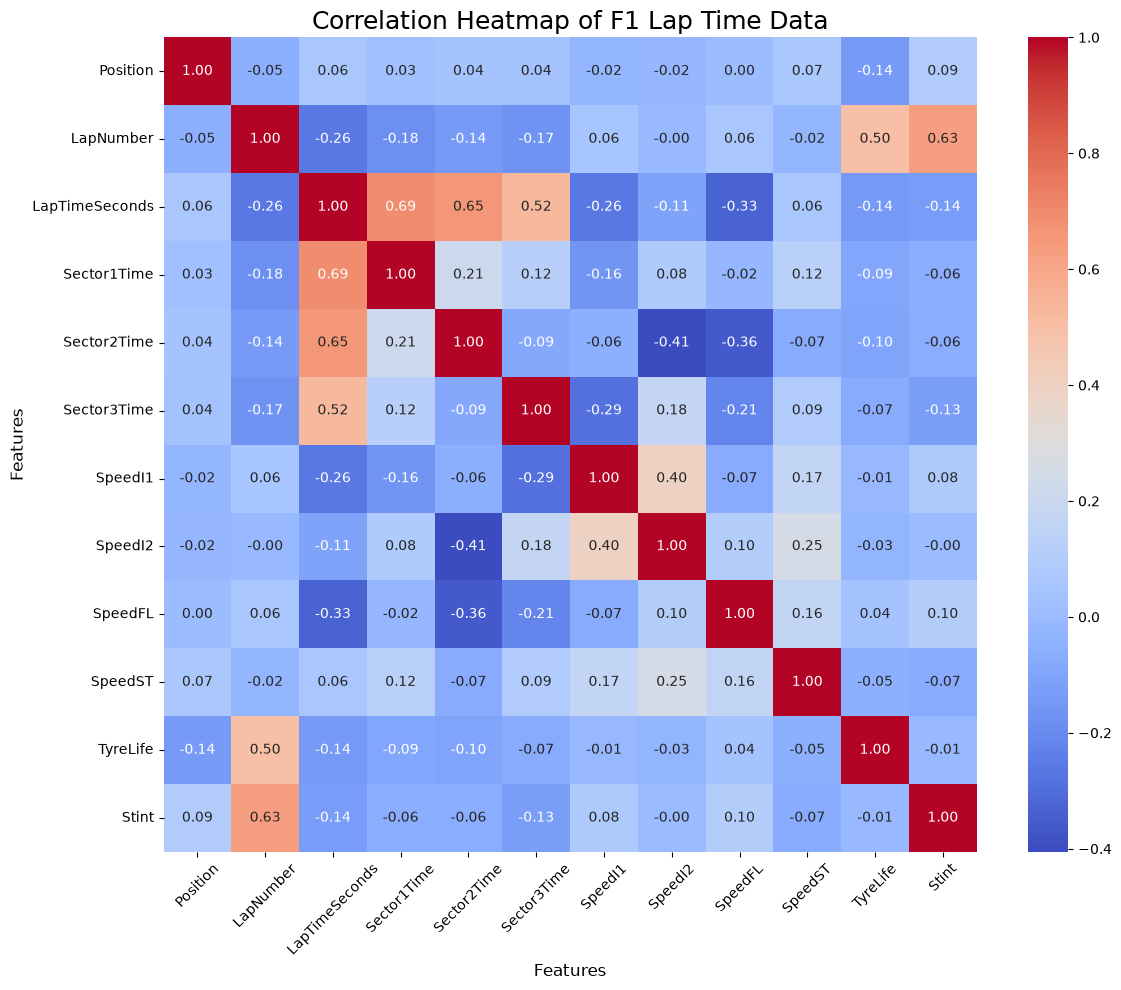

In [10]:
# Correlation Heatmap
numerical_columns = ['Position', 'LapNumber', 'LapTimeSeconds', 
                     'Sector1Time', 'Sector2Time', 'Sector3Time',
                     'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 
                     'TyreLife', 'Stint']


df_analysis = df_full_clean.copy()
df_analysis = df_analysis[numerical_columns]

plt.figure(figsize=(12, 10))
sns.heatmap(df_analysis.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of F1 Lap Time Data", fontsize=18)
plt.xlabel("Features", fontsize=12)
plt.tick_params(axis='x', labelrotation=45)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.savefig(eda_plots_dir / "01_correlation_heatmap.png", dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

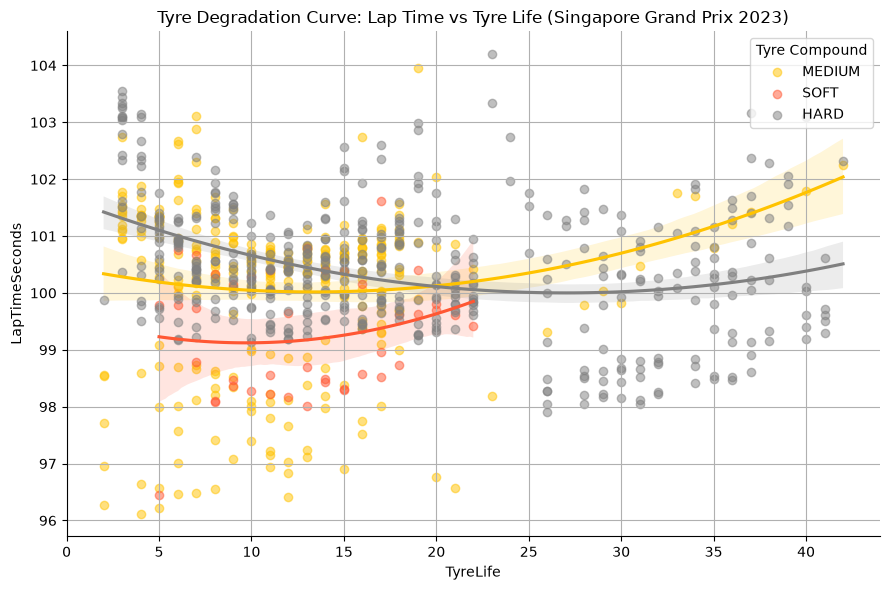

<Figure size 1000x600 with 0 Axes>

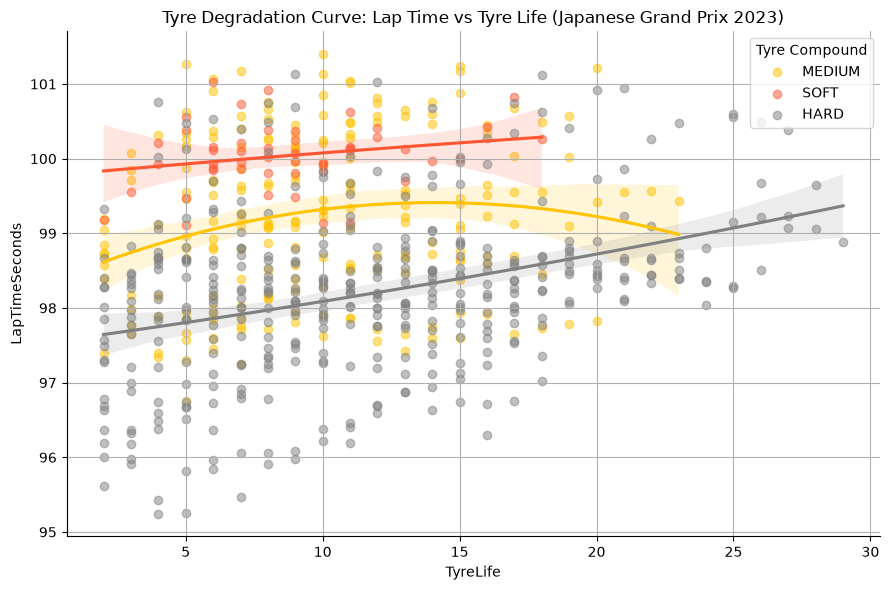

<Figure size 1000x600 with 0 Axes>

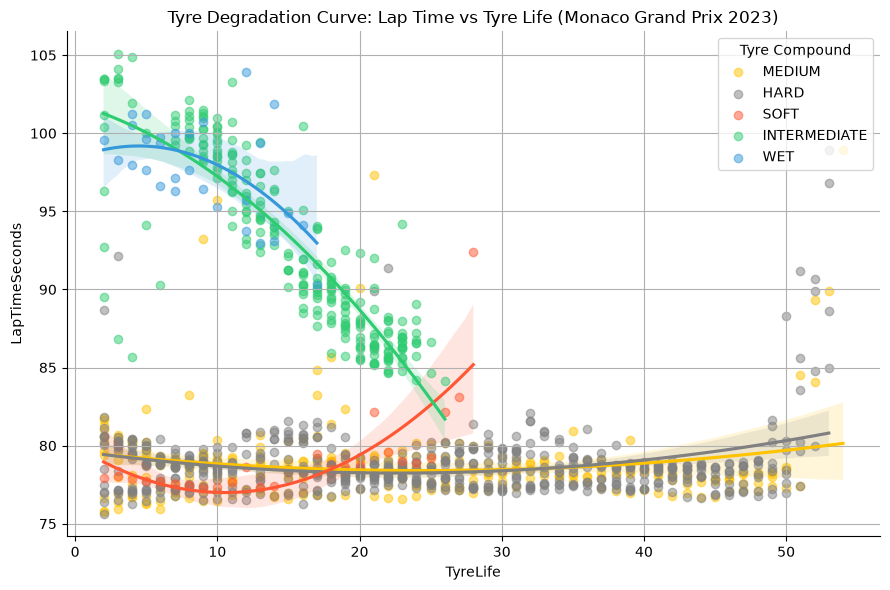

In [11]:
# Tyre Degradation Curve: Lap Time vs Tyre Life

def plot_tyre_degradation(df, event='Italian Grand Prix', year=2023, png_name='tyre_degradation_curve'):
    sample_df = df[(df['Event'] == event) & (df['Year'] == year)]

    # only keep data where all the track status flags are 0 (no safety car, no red flag, no VSC, no pit closed, no SC ending)
    sample_df = sample_df[(sample_df['IsSafetyCar'] == 0) & 
                           (sample_df['IsRedFlag'] == 0) & 
                           (sample_df['IsVSC'] == 0) & 
                           (sample_df['IsPitClosed'] == 0) & 
                           (sample_df['IsSCEnding'] == 0)]
    
    # cap the lap times to a maximum of 120 seconds to remove outliers
    sample_df = sample_df[sample_df['LapTimeSeconds'] <= 110]

    color_palette = {
        'SOFT': '#FF5733',          # Red
        'MEDIUM': '#FFC300',        # Yellow
        'HARD': '#808080',          # Gray
        'INTERMEDIATE': '#2ECC71',  # Green
        'WET': '#3498DB'            # Blue
    }
    plt.figure(figsize=(10, 6))
    sns.lmplot(
        data=sample_df, 
        x='TyreLife', 
        y='LapTimeSeconds', 
        hue='Compound', 
        palette=color_palette,
        height=6, 
        aspect=1.5,
        scatter_kws={'alpha': 0.5},
        order=2,
        legend=False
    )
    plt.title(f'Tyre Degradation Curve: Lap Time vs Tyre Life ({event} {year})')
    plt.grid(True)
    plt.legend(title='Tyre Compound', loc='upper right')
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()



plot_tyre_degradation(df_full_clean, event='Singapore Grand Prix', year=2023, png_name='02_tyre_degradation_Singapore_2023.png')
plot_tyre_degradation(df_full_clean, event='Japanese Grand Prix',  year=2023, png_name='03_tyre_degradation_Japanese_2023.png')
plot_tyre_degradation(df_full_clean, event='Monaco Grand Prix',    year=2023, png_name='04_tyre_degradation_Monaco_2023.png')

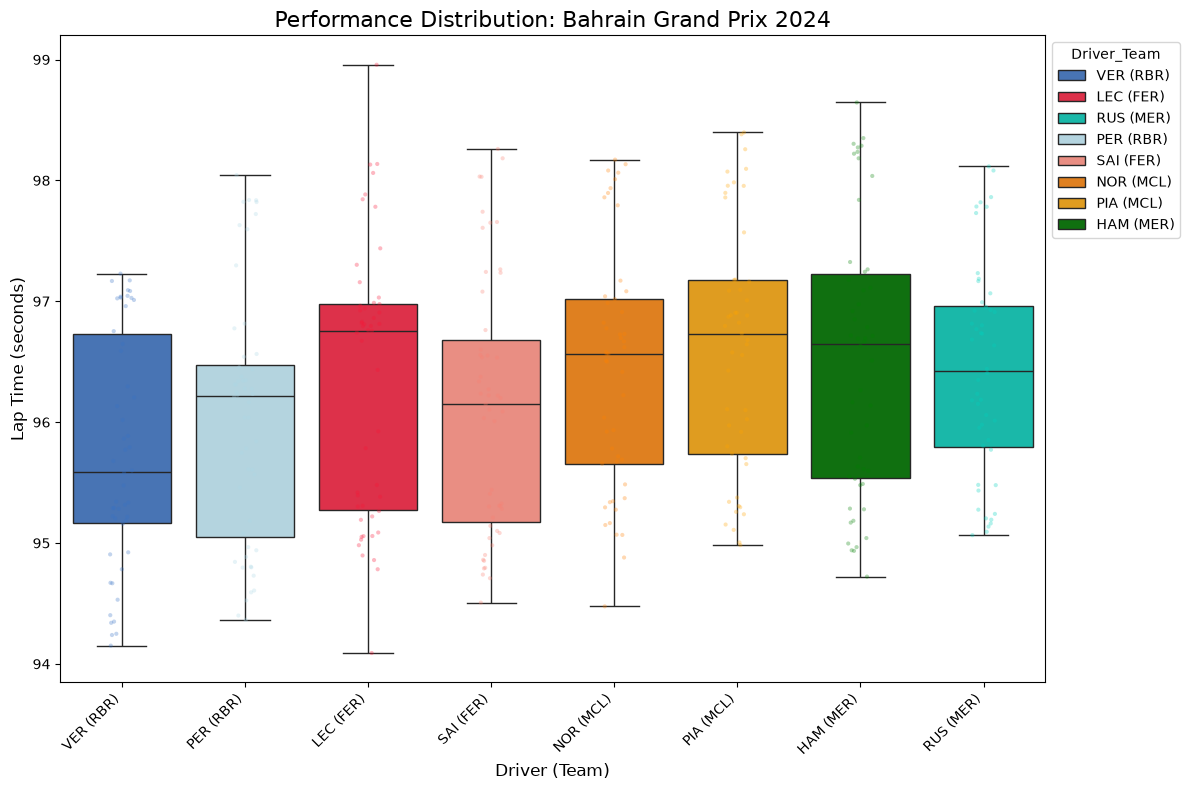

In [12]:
# Driver and Team Effect on Lap Time
def plot_driver_team_effect(df, event='Singapore Grand Prix', year=2023, png_name='driver_team_effect'):
    # Filter the dataframe for the specified event and year, and only include the big 4 teams
    team_abbr = {'Red Bull Racing': 'RBR', 'Ferrari': 'FER', 'McLaren': 'MCL', 'Mercedes': 'MER'}
    subset = df[(df['Team'].isin(team_abbr.keys())) & (df['Event'] == event) & (df['Year'] == year)].copy()
    subset['Driver_Team'] = subset['Driver'] + ' (' + subset['Team'].map(team_abbr) + ')'

    custom_order = ['VER (RBR)', 'PER (RBR)', 'LEC (FER)', 'SAI (FER)', 'NOR (MCL)', 'PIA (MCL)', 'HAM (MER)', 'RUS (MER)']

    color_map = {
        'VER (RBR)': '#3671C6', 'PER (RBR)': 'lightblue',
        'LEC (FER)': '#F91536', 'SAI (FER)': 'salmon',
        'NOR (MCL)': '#FF8000', 'PIA (MCL)': '#FFA500',
        'HAM (MER)': 'green', 'RUS (MER)': '#00D2BE'
    }

    plt.figure(figsize=(12, 8))

    sns.boxplot(
        data=subset, x='Driver_Team', y='LapTimeSeconds', 
        hue='Driver_Team',       
        palette=color_map, 
        order=custom_order,      
        fliersize=0,
        legend=True             
    )
    sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))
    
    sns.stripplot(
        data=subset, x='Driver_Team', y='LapTimeSeconds', 
        hue='Driver_Team',       
        palette=color_map,
        order=custom_order,
        size=3, alpha=0.3,
        legend=False             
    )

    plt.title(f'Performance Distribution: {event} {year}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Driver (Team)', fontsize=12)
    plt.ylabel('Lap Time (seconds)', fontsize=12)
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()

plot_driver_team_effect(df_full_clean, event='Bahrain Grand Prix', year=2024, png_name='05_driver_team_effect_Bahrain_2024.png')

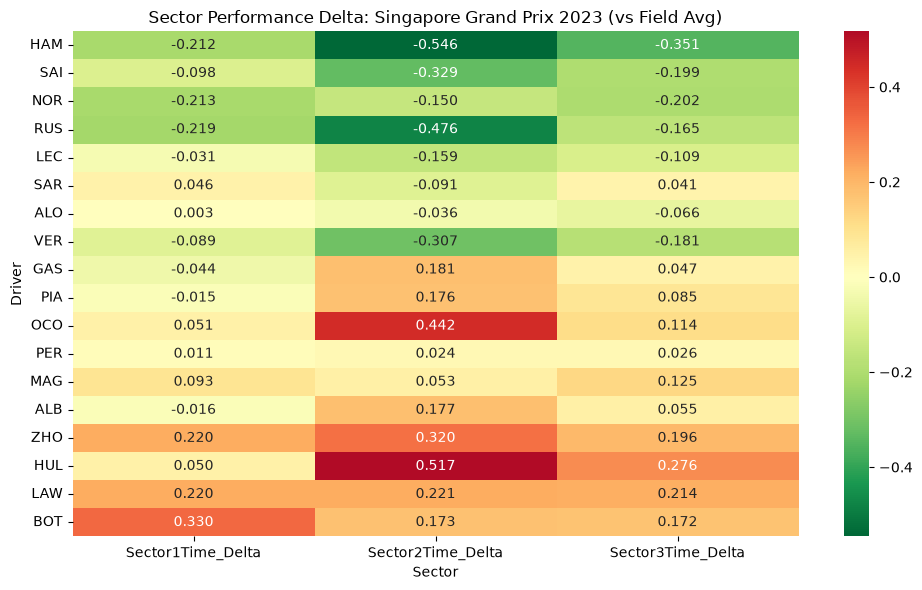

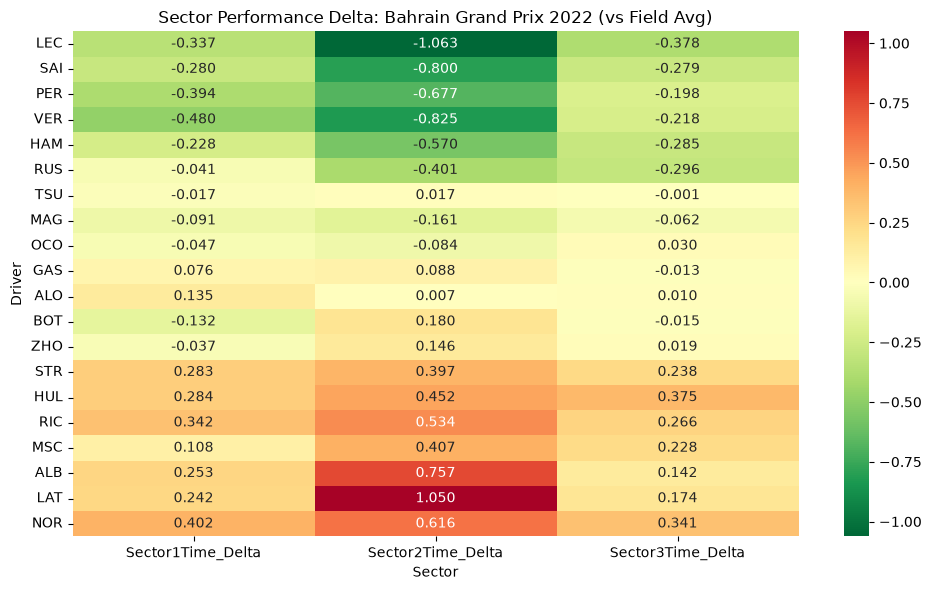

In [13]:
# Sector Performance Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

def plot_sector_performance_heatmap(df, event='Singapore Grand Prix', year=2023, png_name='sector_performance_heatmap'):
    # 1. Filter the dataframe for the specified event and year
    subset = df[(df['Event'] == event) & (df['Year'] == year)].copy()
    sector_cols = ['Sector1Time', 'Sector2Time', 'Sector3Time']

    # 2. Calculate the delta from the mean for each sector
    for col in sector_cols:
        subset[f'{col}_Delta'] = subset[col] - subset[col].mean()

    subset = subset.dropna(subset=['LapTimeSeconds'])
    driver_order = subset.groupby('Driver')['LapTimeSeconds'].median().sort_values().index

    # 4. Pivot the dataframe to have drivers as rows and sectors as columns
    pivot_df = subset.pivot_table(index='Driver', values=[f'{c}_Delta' for c in sector_cols])
    pivot_df = pivot_df.reindex(driver_order)
    
    # 5. Create the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, cmap='RdYlGn_r', center=0, fmt=".3f")
    plt.title(f'Sector Performance Delta: {event} {year} (vs Field Avg)')
    plt.xlabel('Sector')
    plt.ylabel('Driver')
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()

plot_sector_performance_heatmap(df_full_clean, event='Singapore Grand Prix', year=2023, png_name='06_sector_performance_heatmap_Singapore_2023.png')
plot_sector_performance_heatmap(df_full_clean, event='Bahrain Grand Prix', year=2022, png_name='07_sector_performance_heatmap_Bahrain_2022.png')

<Figure size 1000x600 with 0 Axes>

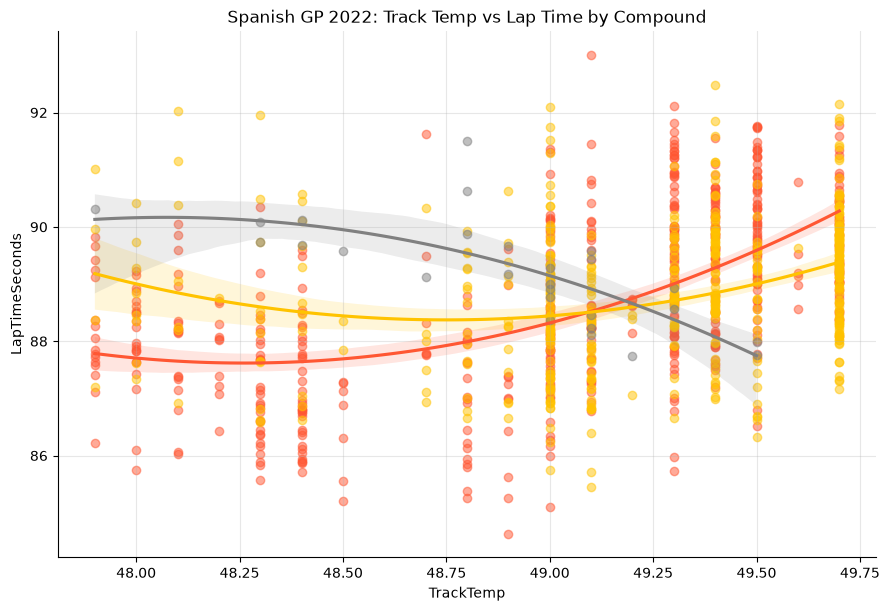

In [14]:
# Scatter Plot: Track Temperature vs Lap Time by Compound

# Filter the dataframe for the Singapore Grand Prix 2023
spanish_2022 = df_full_clean[(df_full_clean['Year'] == 2022) & (df_full_clean['Event'] == 'Spanish Grand Prix')]

color_palette = {
    'SOFT': '#FF5733',          # Red
    'MEDIUM': '#FFC300',        # Yellow
    'HARD': '#808080',          # Gray
    'INTERMEDIATE': '#2ECC71',  # Green
    'WET': '#3498DB'            # Blue
}

# plot the scatter plot with regression lines for each compound
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=spanish_2022, 
    x='TrackTemp', 
    y='LapTimeSeconds', 
    hue='Compound', 
    palette=color_palette,
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    order=2,
    legend=False
)

plt.title('Spanish GP 2022: Track Temp vs Lap Time by Compound')
plt.grid(True, alpha=0.3)
plt.savefig(eda_plots_dir / "08_track_temp_vs_lap_time_Spanish_2022.png", dpi=300)
plt.show()

# Feature Engineering

**Additional Feature Engineering & Data Notes**

1. **Extended Environmental & Compound Indexing**
   * **Humidity & Pressure:** Atmospheric density affects downforce/vertical load and tire cooling, shifting optimal tire working windows.
   * **`TrackTemp_Normalized_By_Compound`:** Interaction feature mapping track surface temperature against Pirelli compound hardness (C1–C5) to model compound-specific thermal degradation.

2. **Regulatory Shift Handling (`RuleSet`)**
   * **Categorical Rule Flag:** Include discrete rule-epoch indicators (e.g., `2018–2021`, `2022–2025`, `2026+`) to account for structural shifts in vehicle mass, aerodynamics, and tire physics.

3. **Dynamic Vehicle Physics & Performance Drift**
   * **Fuel Burn & Mass Sensitivity:** Model dynamic vehicle weight loss (~1.5 kg/lap) to unmask underlying tire degradation from weight-reduction pace gains (~0.3s / 10kg).
   * **In-Season Upgrades:** Track team baseline pace shifts across major aerodynamic/chassis update packages.

4. **Time-Decay Sample Weighting**
   * **Exponential Recency Weighting:** Apply sample weights $W_t = e^{-\lambda (T_{\text{current}} - T_{\text{sample}})}$ during LSTM/Bayesian training to prioritize recent car iterations and modern tire formulations.

In [235]:
# Feature Engineering: LapTimeDelta, TyreLifeSquared, Stint_Age, Relative_Gap, DRS_Active

def engineer_features(df, delta_thre, gap_thre):
    df = df.copy()
    
    # 1. Sort the dataframe by Year, Event, Driver, and LapNumber to ensure proper time-series continuity
    df = df.sort_values(['Year', 'Event', 'Driver', 'LapNumber'])
    
    # --- LapTimeDelta ---
    df['LapTimeDelta'] = df.groupby(['Year', 'Event', 'Driver'])['LapTimeSeconds'].diff()
    df['LapTimeDelta'] = df['LapTimeDelta'].fillna(0).clip(lower=0-delta_thre, upper=delta_thre)

    
    # --- Tyre & Stint Features ---
    df['TyreLifeSquared'] = df['TyreLife'] ** 2
    df['Stint_Age'] = df.groupby(['Year', 'Event', 'Driver', 'Stint']).cumcount() + 1
    
    # --- Relative Gap & DRS ---
    df = df.sort_values(['Year', 'Event', 'LapNumber', 'Position'])
    
    # Position=1 (first car) has no car in front, so .diff() will be NaN -> fill with 999 to indicate leading Free Air
    df['Relative_Gap'] = df.groupby(['Year', 'Event', 'LapNumber'])['Time'].diff().fillna(999)
    
    # DRS is active if the relative gap is between 0 and 1 second (inclusive)
    df['DRS_Active'] = ((df['Relative_Gap'] > 0.0) & (df['Relative_Gap'] <= 1.0)).astype(int)
    
    # Clip Relative_Gap to a maximum of 10.0 (first car with 999 will become 10.0, avoiding issues with Scaler)
    df['Relative_Gap'] = df['Relative_Gap'].clip(upper=gap_thre)
    
    # Re-sort the dataframe by Year, Event, Driver, and LapNumber to maintain time-series continuity (important for LSTM)
    df = df.sort_values(['Year', 'Event', 'Driver', 'LapNumber']).reset_index(drop=True)
    
    return df

# Apply feature engineering to the cleaned dataframe
df_full_eng = engineer_features(df_full_clean, 5, 15)
df_full_eng.drop(columns=['Time', 'Position'], inplace=True, errors='ignore')

print(df_full_eng.columns)

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'LapTimeSeconds',
       'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife',
       'FreshTyre', 'Stint', 'IsSafetyCar', 'IsRedFlag', 'IsVSC',
       'IsPitClosed', 'IsSCEnding', 'AirTemp', 'TrackTemp', 'Rainfall',
       'LapTimeDelta', 'TyreLifeSquared', 'Stint_Age', 'Relative_Gap',
       'DRS_Active'],
      dtype='object')


Feature Statistics: count    115725.000000
mean         -0.067443
std           0.714652
min          -5.000000
25%          -0.272000
50%          -0.015000
75%           0.204000
max           5.000000
Name: LapTimeDelta, dtype: float64
Extreme LapTimeDelta values (> 5 or < -5): 0 rows


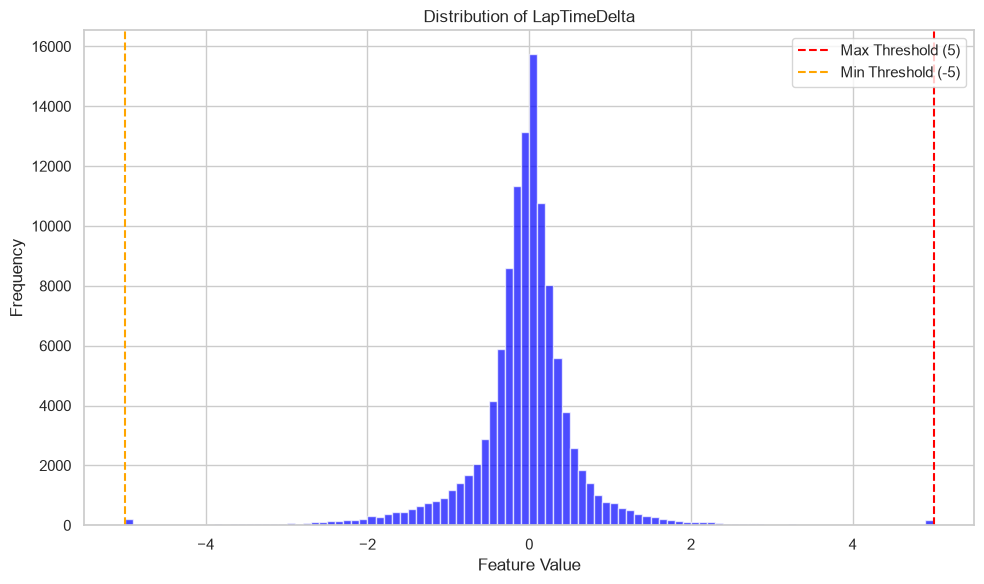

Feature Statistics: count    115725.000000
mean          5.079844
std           4.995463
min           0.002000
25%           1.255000
50%           2.831000
75%           7.496000
max          15.000000
Name: Relative_Gap, dtype: float64
Extreme Relative_Gap values (> 15 or < 0): 0 rows


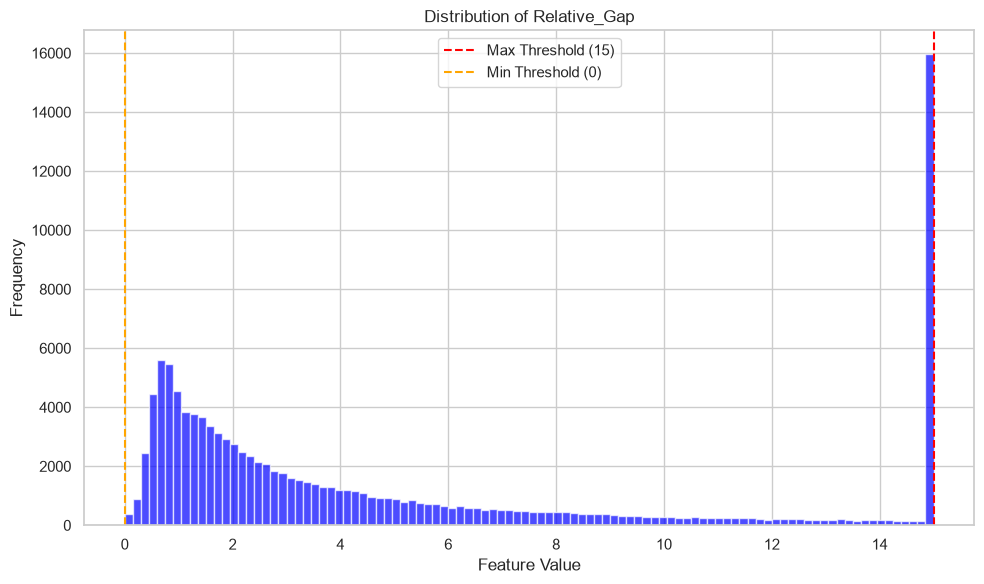

In [236]:
# A small check on numerical features to see if they are within reasonable ranges

def check_extreme_values(df, feature, thre_min=5, thre_max=5, save_path=None):
    print(f"Feature Statistics: {df[feature].describe()}")
    extreme_deltas = df[(df[feature] > thre_max) | (df[feature] < thre_min)]
    print(f"Extreme {feature} values (> {thre_max} or < {thre_min}): {len(extreme_deltas)} rows")

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.hist(df[feature], bins=100, color='blue', alpha=0.7)
    # add vertical lines for thresholds
    plt.axvline(x=thre_max, color='red', linestyle='--', label=f'Max Threshold ({thre_max})')
    plt.axvline(x=thre_min, color='orange', linestyle='--', label=f'Min Threshold ({thre_min})')
    
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of ' + feature)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(preprocessing_plots_dir / save_path, dpi=300)
    plt.show()


check_extreme_values(df_full_eng, 'LapTimeDelta', thre_min=-5, thre_max=5, save_path="01_lap_time_delta_dist.png")

check_extreme_values(df_full_eng, 'Relative_Gap', thre_min=0, thre_max=15, save_path="02_relative_gap_dist.png")

In [237]:
# Reorder to put target feature at the end for better readability and model training
desired_order = [   'Year', 'Event', 'Driver', 'Team', 'LapNumber',                                     # Basic Info
                    'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest',                      # Lap performance
                    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',                                         # Speed
                    'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife', 'TyreLifeSquared', 'Compound',       # Tyre Strategy
                    'Relative_Gap', 'DRS_Active',                                                       # Relative Gap and DRS
                    'IsSafetyCar', 'IsRedFlag', 'IsVSC','IsPitClosed', 'IsSCEnding',                    # Track Status
                    'AirTemp', 'TrackTemp', 'Rainfall',                                                 # Weather Conditions
                    'LapTimeSeconds','LapTimeDelta',                                                    # Target Feature
]

 
df_no_extreme = reorder_columns(df_full_eng, desired_order)
df_no_extreme.columns

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'Sector1Time',
       'Sector2Time', 'Sector3Time', 'IsPersonalBest', 'SpeedI1', 'SpeedI2',
       'SpeedFL', 'SpeedST', 'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife',
       'TyreLifeSquared', 'Compound', 'Relative_Gap', 'DRS_Active',
       'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
       'AirTemp', 'TrackTemp', 'Rainfall', 'LapTimeSeconds', 'LapTimeDelta'],
      dtype='object')

# Preprocessor - Fit and Transform of Split Data

In [238]:
# Feature Groups / Categorization for Preprocessing

# Embedding features
# categorical features with many unique values, suitable for embedding layers in neural networks
embedding_features = ['Year', 'Event', 'Driver', 'Team']          

# One-hot encoding features
# categorical features with a limited number of unique values, suitable for one-hot encoding
onehot_features = ['Compound']                   

# Robust scaling features
# numerical features that may have outliers, suitable for robust scaling
robust_features = [
    'LapTimeDelta', 'LapTimeSeconds', 
    'Sector1Time', 'Sector2Time', 'Sector3Time',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
    'Relative_Gap',
    'TrackTemp', 'AirTemp'
]

# Min-max scaling features
# numerical features that are bounded and can be scaled to a specific range, suitable for min-max scaling
minmax_features = [
    'LapNumber', 'Stint', 'Stint_Age', 
    'TyreLife', 'TyreLifeSquared'
]

# Boolean features
# binary features that represent true/false conditions, suitable for boolean representation
bool_features = [
    'IsPersonalBest', 'FreshTyre', 'DRS_Active',
    'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
    'Rainfall',
]

In [239]:
# Make sure to validate and cast the feature types before passing into F1Preprocessor

def validate_and_cast_feature_types(df, 
                                   embedding_cols=embedding_features, 
                                   onehot_cols=onehot_features, 
                                   robust_cols=robust_features, 
                                   minmax_cols=minmax_features, 
                                   bool_cols=bool_features):
    """
    Validates and casts DataFrame columns to their expected data types 
    before passing into F1Preprocessor.
    """
    df = df.copy()
    
    # 1. Cast Boolean features to explicit bool (True / False)
    for col in bool_cols:
        if col in df.columns:
            # fillna(0) then cast to bool: 1/1.0/True -> True, 0/0.0/False/NaN -> False
            df[col] = df[col].fillna(0).astype(bool)
            
    # 2. Cast Numeric (Robust & MinMax) features to float64
    numeric_cols = robust_cols + minmax_cols
    for col in numeric_cols:
        if col in df.columns:
            # pd.to_numeric with errors='coerce' will convert invalid parsing to NaN, then we cast to float64
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')
            
    # 3. Cast Categorical (Embedding & One-Hot) features to string/object
    cat_cols = embedding_cols + onehot_cols
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
            
    return df

df_no_extreme = validate_and_cast_feature_types(df_no_extreme)
print(df_no_extreme.dtypes)


Year                object
Event               object
Driver              object
Team                object
LapNumber          float64
Sector1Time        float64
Sector2Time        float64
Sector3Time        float64
IsPersonalBest        bool
SpeedI1            float64
SpeedI2            float64
SpeedFL            float64
SpeedST            float64
Stint              float64
Stint_Age          float64
FreshTyre             bool
TyreLife           float64
TyreLifeSquared    float64
Compound            object
Relative_Gap       float64
DRS_Active            bool
IsSafetyCar           bool
IsRedFlag             bool
IsVSC                 bool
IsPitClosed           bool
IsSCEnding            bool
AirTemp            float64
TrackTemp          float64
Rainfall              bool
LapTimeSeconds     float64
LapTimeDelta       float64
dtype: object


C:\Users\Bevis\AppData\Local\Temp\ipykernel_20536\3765063751.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(0).astype(bool)


In [240]:
# Preprocessor Class for F1 Data

class F1Preprocessor:

    def __init__(
        self,
        embedding_cols=embedding_features,
        onehot_cols=onehot_features,
        robust_cols=robust_features,
        minmax_cols=minmax_features,
        bool_cols=bool_features,
    ):
        self.embedding_cols = embedding_cols or []
        self.onehot_cols = onehot_cols or []
        self.robust_cols = robust_cols or []
        self.minmax_cols = minmax_cols or []
        self.bool_cols = bool_cols or []

        self.label_encoders = {}
        self.onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        self.robust_scaler = RobustScaler()
        self.minmax_scaler = MinMaxScaler()

        self.valid_onehot = []
        self.valid_robust = []
        self.valid_minmax = []
        self.valid_bool = []

        self.ordered_cont_cols = ([])
        self.feature_names_all = []
        self.feature_names_cat = []
        self.feature_names_cont = []

    # ==========================================
    # 1. MODULAR FIT METHODS
    # ==========================================
    def fit_categoricals(self, df):
        for col in self.embedding_cols:
            if col in df.columns:
                unique = sorted(df[col].dropna().unique())
                self.label_encoders[col] = {
                    val: i + 1 for i, val in enumerate(unique)
                }
        return self

    def fit_continuous(self, df):
        # Lock column existence based on training set
        self.valid_onehot = [c for c in self.onehot_cols if c in df.columns]
        self.valid_robust = [c for c in self.robust_cols if c in df.columns]
        self.valid_minmax = [c for c in self.minmax_cols if c in df.columns]
        self.valid_bool = [c for c in self.bool_cols if c in df.columns]

        if self.valid_onehot:
            self.onehot_encoder.fit(df[self.valid_onehot])
        if self.valid_robust:
            self.robust_scaler.fit(df[self.valid_robust])
        if self.valid_minmax:
            self.minmax_scaler.fit(df[self.valid_minmax])

        # Save explicit continuous column order matching transform_cont output exactly
        self.ordered_cont_cols = (
            self.valid_onehot
            + self.valid_robust
            + self.valid_minmax
            + self.valid_bool
        )
        return self

    def fit(self, df_train, df_global=None):
        """Backward-compatible master fit."""
        global_data = df_global if df_global is not None else df_train
        self.fit_categoricals(global_data)
        self.fit_continuous(df_train)
        self._build_feature_names(df_train)
        return self

    # ==========================================
    # 2. MODULAR TRANSFORM METHODS
    # ==========================================
    def transform_cat(self, df):
        """Returns 2D NumPy array of 1-indexed categorical integer features."""
        cat_cols = []
        for col in self.embedding_cols:
            if col in df.columns:
                vals = (
                    df[col]
                    .map(self.label_encoders.get(col, {}))
                    .fillna(0)
                    .astype(np.int64)
                    .values.reshape(-1, 1)
                )
                cat_cols.append(vals)

        return np.hstack(cat_cols) if cat_cols else np.empty((len(df), 0))

    def transform_cont(self, df):
        cont_blocks = []

        # 1. One-Hot Features
        if self.valid_onehot:
            oh_array = self.onehot_encoder.transform(df[self.valid_onehot])
            cont_blocks.append(oh_array)

        # 2. Robust Features
        if self.valid_robust:
            rob_array = self.robust_scaler.transform(df[self.valid_robust])
            cont_blocks.append(rob_array)

        # 3. MinMax Features
        if self.valid_minmax:
            mm_array = self.minmax_scaler.transform(df[self.valid_minmax])
            cont_blocks.append(mm_array)

        # 4. Bool Features
        if self.valid_bool:
            bool_array = df[self.valid_bool].astype(int).to_numpy()
            if bool_array.ndim == 1:
                bool_array = bool_array.reshape(-1, 1)
            cont_blocks.append(bool_array)

        return (
            np.hstack(cont_blocks)
            if cont_blocks
            else np.empty((len(df), 0), dtype=np.float32)
        )
    
    def transform(self, df):
        """Combined transformation matrix (Categoricals + Continuous)."""
        x_cat = self.transform_cat(df)
        x_cont = self.transform_cont(df)

        if x_cat.size == 0:
            return x_cont
        if x_cont.size == 0:
            return x_cat
        return np.hstack([x_cat, x_cont])

    # ==========================================
    # 3. UTILITY & DECODING METHODS
    # ==========================================
    def _build_feature_names(self, df):
        self.feature_names_cat = []
        self.feature_names_cont = []

        # 1. Embedding / Categorical Columns
        for col in self.embedding_cols:
            if col in df.columns:
                self.feature_names_cat.append(col)

        # 2. Continuous Columns (Must strictly match transform_cont order!)
        if self.valid_onehot:
            oh_names = self.onehot_encoder.get_feature_names_out(self.valid_onehot)
            self.feature_names_cont.extend(list(oh_names))

        self.feature_names_cont.extend(self.valid_robust)
        self.feature_names_cont.extend(self.valid_minmax)
        self.feature_names_cont.extend(self.valid_bool)

        # 3. Master Global List
        self.feature_names_all = (self.feature_names_cat + self.feature_names_cont)

    def get_feature_names(self, feat_type="all"):
        if feat_type == "all":
            return self.feature_names_all.copy()
        elif feat_type == "cat":
            return self.feature_names_cat.copy()
        elif feat_type == "cont":
            return self.feature_names_cont.copy()
        raise ValueError(f"Invalid feat_type '{feat_type}'. Choose 'all', 'cat', or 'cont'.")

    def get_col_idx(self, col_name, rel="all"):
        target_list = getattr(self, f"feature_names_{rel}", None)

        if target_list is None:
            raise ValueError(f"Invalid mode '{rel}'. Must be 'all', 'cat', or 'cont'.")

        if col_name in target_list:
            return target_list.index(col_name)

        raise ValueError(f"Column '{col_name}' not found in feature_names_{rel}!")

    # ==========================================
    # 4. UTILITY & DECODING METHODS
    # ==========================================
    def inverse_transform_cat(self, col_name, encoded_val):
        if col_name not in self.label_encoders:
            return encoded_val

        rev_map = {v: k for k, v in self.label_encoders[col_name].items()}
        rev_map[0] = "<UNK>"

        if isinstance(encoded_val, (list, np.ndarray, torch.Tensor)):
            if isinstance(encoded_val, torch.Tensor):
                encoded_val = encoded_val.cpu().numpy()
            return [rev_map.get(int(v), "<UNK>") for v in np.ravel(encoded_val)]

        return rev_map.get(int(encoded_val), "<UNK>")

    def inverse_transform_cont(self, scaled_values, col_name):
        arr = np.array(scaled_values, dtype=np.float32)

        if col_name in self.valid_robust:
            col_idx = self.valid_robust.index(col_name)
            center = self.robust_scaler.center_[col_idx]
            scale = self.robust_scaler.scale_[col_idx]
            return arr * scale + center
        elif col_name in self.valid_minmax:
            col_idx = self.valid_minmax.index(col_name)
            min_val = self.minmax_scaler.data_min_[col_idx]
            max_val = self.minmax_scaler.data_max_[col_idx]
            return arr * (max_val - min_val) + min_val
        else:
            return arr


In [241]:
# Data split

# Sort by Year, Event, Driver, and LapNumber to ensure proper time-series continuity before splitting
df_raw = df_no_extreme.copy()
df_raw = df_raw.sort_values(by=['Year', 'Event', 'Driver', 'LapNumber']).reset_index(drop=True)

df_raw['Year'] = df_raw['Year'].astype(str)
train_df = df_raw[df_raw['Year'].isin(['2020', '2021', '2022', '2023'])].copy()
val_df   = df_raw[df_raw['Year'] == '2024'].copy()
test_df  = df_raw[df_raw['Year'] >= '2025'].copy()

print(f"Train shape: {train_df.shape}, Val shape: {val_df.shape}, Test shape: {test_df.shape}\n")

print(train_df.columns)

Train shape: (72520, 31), Val shape: (22344, 31), Test shape: (20861, 31)

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'Sector1Time',
       'Sector2Time', 'Sector3Time', 'IsPersonalBest', 'SpeedI1', 'SpeedI2',
       'SpeedFL', 'SpeedST', 'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife',
       'TyreLifeSquared', 'Compound', 'Relative_Gap', 'DRS_Active',
       'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
       'AirTemp', 'TrackTemp', 'Rainfall', 'LapTimeSeconds', 'LapTimeDelta'],
      dtype='object')


In [242]:
# Fit the preprocessor on the training data and transform all datasets
preprocessor = F1Preprocessor()

# Fit only the train set
# train df -> transform_cont
# df_raw   -> transform_cat
preprocessor.fit(train_df, df_raw)                    

X_train = preprocessor.transform(train_df)
X_val   = preprocessor.transform(val_df)
X_test  = preprocessor.transform(test_df)

# Check for NaN and Inf values in the transformed datasets
print(f"Training data - Any NaN: {np.isnan(X_train).any()}, Any Inf: {np.isinf(X_train).any()}")
print(f"Validation data - Any NaN: {np.isnan(X_val).any()}, Any Inf: {np.isinf(X_val).any()}")
print(f"Test data - Any NaN: {np.isnan(X_test).any()}, Any Inf: {np.isinf(X_test).any()}")

print(f"feature_names_out: {preprocessor.get_feature_names()}")

Training data - Any NaN: False, Any Inf: False
Validation data - Any NaN: False, Any Inf: False
Test data - Any NaN: False, Any Inf: False
feature_names_out: ['Year', 'Event', 'Driver', 'Team', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 'LapTimeDelta', 'LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Relative_Gap', 'TrackTemp', 'AirTemp', 'LapNumber', 'Stint', 'Stint_Age', 'TyreLife', 'TyreLifeSquared', 'IsPersonalBest', 'FreshTyre', 'DRS_Active', 'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'Rainfall']


           Feature Train_Min Train_Max  Transformed_Min  Transformed_Max
0     LapTimeDelta      -5.0       5.0       -10.190184        10.259714
1   LapTimeSeconds    56.319   129.869        -1.764343         2.538148
2      Sector1Time    16.632    46.151        -1.465178         2.279462
3      Sector2Time    17.606    54.277        -1.736130         2.502312
4      Sector3Time    16.396    46.438        -1.370050         2.944315
5          SpeedI1      95.0     349.0        -3.214286         1.321429
6          SpeedI2     115.0     341.0        -2.764706         1.666667
7          SpeedFL     140.0     348.0        -3.045455         1.681818
8          SpeedST     186.0     361.0        -6.000000         3.210526
9     Relative_Gap     0.002      15.0        -0.439752         1.790683
10       TrackTemp      13.8      57.5        -1.590909         1.719697
11         AirTemp       8.9      37.2        -2.119403         2.104478


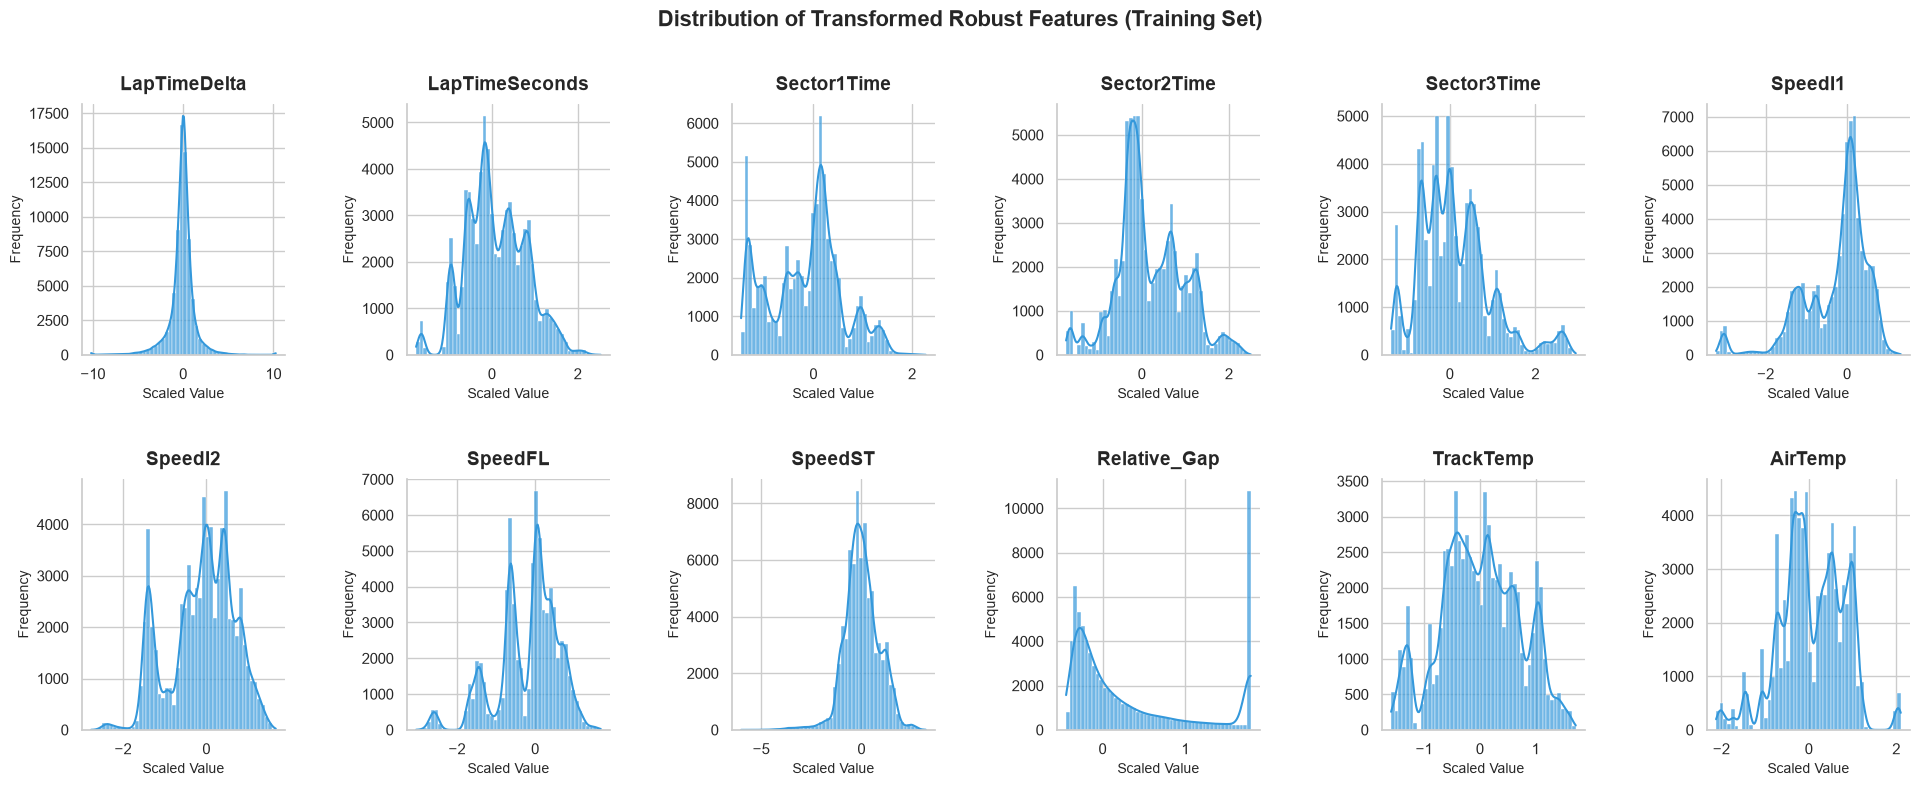

In [243]:
# Compare the max and min of features in X_train and train_df to ensure scaling is correct

feature_names = preprocessor.get_feature_names()

df_feature_stats = pd.DataFrame({
    'Feature': feature_names,
    'Train_Min': [train_df[col].min() if col in train_df.columns else np.nan for col in feature_names],
    'Train_Max': [train_df[col].max() if col in train_df.columns else np.nan for col in feature_names],
    'Transformed_Min': [X_train[:, i].min() for i in range(X_train.shape[1])],
    'Transformed_Max': [X_train[:, i].max() for i in range(X_train.shape[1])]
})

# only show the robust features for comparison
robust_feature_stats = df_feature_stats[df_feature_stats['Feature'].isin(robust_features)].reset_index(drop=True)
print(robust_feature_stats)


# check the distribution of the transformed features to ensure they are within expected ranges
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 8))  

for i, feature in enumerate(robust_features):
    if feature in feature_names:
        idx = feature_names.index(feature)
        ax = plt.subplot(2, 6, i + 1)
        sns.histplot(X_train[:, idx], bins=50, kde=True, 
                     color='#3498db', edgecolor='white', alpha=0.7, ax=ax)
        ax.set_title(f'{feature}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Scaled Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        sns.despine()
plt.tight_layout(pad=3.0)
plt.suptitle("Distribution of Transformed Robust Features (Training Set)", fontsize=16, fontweight='bold', y=1.02)
plt.savefig(preprocessing_plots_dir / "03_Transformed_Robust_Features_Distribution.png", dpi=300)
plt.show()

# Sequence Dataset - Create Sliding Window

In [188]:
# Create a PyTorch Dataset for Sequence Modeling

class F1SequenceDataset(Dataset):

    def __init__(
        self,
        data_matrix,
        idx_map,
        seq_len=10,
        forecast_len=5,
    ):
        # Convert numpy matrix to PyTorch tensor once
        if not isinstance(data_matrix, torch.Tensor):
            data_tensor = torch.from_numpy(np.ascontiguousarray(data_matrix))
        else:
            data_tensor = data_matrix

        self.data_cat = data_tensor[:, idx_map["cat_idx"]].long().contiguous()
        self.data_cont = (data_tensor[:, idx_map["cont_idx"]].float().contiguous())

        # 2. Pre-mask unknown continuous future features ONCE 
        # (Zero out target & unobserved continuous features)
        self.data_cont_fut = self.data_cont.clone()
        self.unknown_cont_rel_idx = idx_map["unknown_cont_rel_idx"]

        # Supports either a single column integer or a list of feature indices
        if isinstance(self.unknown_cont_rel_idx, (list, tuple, np.ndarray)):
            self.data_cont_fut[:, self.unknown_cont_rel_idx] = 0.0
        else:
            self.data_cont_fut[:, self.unknown_cont_rel_idx] = 0.0

        # Ensure target is explicitly 2D (N, num_targets)
        target_tensor = data_tensor[:, idx_map["target_idx"]].float()
        if target_tensor.ndim == 1:
            target_tensor = target_tensor.unsqueeze(-1)
        self.data_target = target_tensor.contiguous()

        self.seq_len = seq_len
        self.forecast_len = forecast_len

        # Build valid indices ensuring strictly contiguous sessions/drivers
        self.indices = self._build_valid_indices(data_tensor, idx_map)

    def _build_valid_indices(self, data_tensor, idx_map):
        total_window_len = self.seq_len + self.forecast_len
        num_rows = len(data_tensor)

        if num_rows < total_window_len:
            return np.array([], dtype=int)

        meta_idx = idx_map.get("meta_idx", [0, 1, 2])
        meta_data = data_tensor[:, meta_idx]

        # Ensure ALL rows inside total_window_len share the same metadata
        valid_indices = []
        for i in range(num_rows - total_window_len + 1):
            window_meta = meta_data[i : i + total_window_len]
            if torch.all(window_meta == window_meta[0]):
                valid_indices.append(i)

        return np.array(valid_indices, dtype=int)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.seq_len
        future_end = end + self.forecast_len

        # Fast direct slices without on-the-fly masking logic
        x_cat = self.data_cat[start:end]
        x_cont = self.data_cont[start:end]              # Unmasked history
        x_cat_fut = self.data_cat[end:future_end]
        x_cont_fut = self.data_cont_fut[end:future_end]  # Pre-masked future

        y = self.data_target[end:future_end]

        return x_cat, x_cont, x_cat_fut, x_cont_fut, y

In [250]:
# Feature names & Index mapping

all_feature_names = preprocessor.get_feature_names("all")
cat_feature_names = preprocessor.get_feature_names("cat")
cont_feature_names = preprocessor.get_feature_names("cont")

cat_idx = [preprocessor.get_col_idx(col, "all") for col in cat_feature_names]
cont_idx = [preprocessor.get_col_idx(col, "all") for col in cont_feature_names]
target_idx = preprocessor.get_col_idx("LapTimeDelta", 'all')

# Identify the relative indexes of continuous features that need to be masked in the future sequence

# known_fut_cols = ['Year', 'Event', 'Driver', 'Team', 'LapNumber',
#                   'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife', 'TyreLifeSquared', 
#                   'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 
#                   'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
#                   'AirTemp', 'TrackTemp', 'Rainfall', 
# ]

unknown_fut_cols = [ 
    'LapTimeSeconds', 'LapTimeDelta',
    'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest', 
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 
    'Relative_Gap', 'DRS_Active', 
]

print(f"Continuous feature names: {cont_feature_names}")
unknown_cont_rel_idx = [preprocessor.get_col_idx(col, "cont") for col in unknown_fut_cols]
   
idx_map = {
    # Index in the transformed data matrix (X_train, X_val, X_test)
    "cat_idx": cat_idx,
    "cont_idx": cont_idx,
    "target_idx": target_idx,
    "unknown_cont_rel_idx": unknown_cont_rel_idx,
    "meta_idx": [0, 1, 2],  # Year, Event, Driver
}

print("\n ----- idx_map -----")
print(f"cat_idx ({len(cat_idx)}): {cat_idx}")
print(f"cont_idx ({len(cont_idx)}): {cont_idx}") 
print(f"target_idx: {target_idx}")
print(f"unknown_cont_rel_idx ({len(unknown_cont_rel_idx)}): {unknown_cont_rel_idx}")
print(f"meta_idx: {idx_map['meta_idx']}")


Continuous feature names: ['Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 'LapTimeDelta', 'LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Relative_Gap', 'TrackTemp', 'AirTemp', 'LapNumber', 'Stint', 'Stint_Age', 'TyreLife', 'TyreLifeSquared', 'IsPersonalBest', 'FreshTyre', 'DRS_Active', 'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'Rainfall']

 ----- idx_map -----
cat_idx (4): [0, 1, 2, 3]
cont_idx (31): [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
target_idx: 9
unknown_cont_rel_idx (12): [6, 5, 7, 8, 9, 22, 10, 11, 12, 13, 14, 24]
meta_idx: [0, 1, 2]


In [ ]:
# Check the Tensor shapes and the masking

f1_dataset = F1SequenceDataset(
    data_matrix=X_train,
    idx_map=idx_map,
    seq_len=12,
    forecast_len=3,
)

# Create DataLoader
dataloader = DataLoader(f1_dataset, batch_size=32, shuffle=True)
batch = next(iter(dataloader))

x_cat_b, x_cont_b, x_cat_fut_b, x_cont_fut_b, y_b = batch

# 1. Output the shapes of the tensors to verify correctness
print("\n--- Tensor Shapes Verification ---")
print(f"x_cat_batch shape:     | Expect: (32, {f1_dataset.seq_len}, {len(cat_idx)})  | {x_cat_b.shape}")
print(f"x_cont_batch shape:    | Expect: (32, {f1_dataset.seq_len}, {len(cont_idx)}) | {x_cont_b.shape}")
print(f"x_cat_fut_batch shape: | Expect: (32, {f1_dataset.forecast_len}, {len(cat_idx)})   | {x_cat_fut_b.shape}")
print(f"x_cont_fut_batch shape:| Expect: (32, {f1_dataset.forecast_len}, {len(cont_idx)})  | {x_cont_fut_b.shape}")
print(f"y_batch shape:         | Expect: (32, {f1_dataset.forecast_len}, 1)   | {y_b.shape}")


def verify_dataset_masking(dataset, preprocessor):
  """Prints feature values and asserts that pre-masked future columns are zeroed out."""
  # 1. Fetch the first sample from the dataset
  x_cat, x_cont, x_cat_fut, x_cont_fut, y = dataset[0]

  cont_feature_names = preprocessor.get_feature_names("cont")
  unknown_indices = dataset.unknown_cont_rel_idx

  if isinstance(unknown_indices, int):
    unknown_indices = [unknown_indices]

  print("=" * 60)
  print("DATASET MASKING VERIFICATION")
  print("=" * 60)

  # 2. Check column-by-column status
  print(f"\nTotal Continuous Features: {len(cont_feature_names)}")
  print("\n--- Feature Masking Status ---")
  for idx, name in enumerate(cont_feature_names):
    is_masked = idx in unknown_indices
    status = "MASKED IN FUTURE (0.0)" if is_masked else "UNMASKED IN FUTURE"
    print(f"Index {idx:2d} | [{status}] -> {name}")

  # 3. Inspect values from x_cont (History) vs x_cont_fut (Future)
  print("\n--- First Future Step Sample Values (x_cont_fut[0]) ---")
  for idx in unknown_indices:
    feat_name = cont_feature_names[idx]
    hist_val = x_cont[-1, idx].item()  # Last history step
    fut_val = x_cont_fut[0, idx].item()  # First future step

    print(f"Feature: '{feat_name}' (Index {idx})")
    print(f"  └─ History value (t=-1) : {hist_val:.4f}")
    print(f"  └─ Future value  (t=+1) : {fut_val:.4f}")

    # Assertion check
    assert torch.all(
        x_cont_fut[:, idx] == 0.0
    ), f"ERROR: Column '{feat_name}' at index {idx} was NOT masked in x_cont_fut!"

  print("\n SUCCESS: All specified future continuous features are strictly 0.0!")
  print("=" * 60)


# Run verification test
verify_dataset_masking(f1_dataset, preprocessor)



--- Tensor Shapes Verification ---
x_cat_batch shape:     | Expect: (32, 12, 4)  | torch.Size([32, 12, 4])
x_cont_batch shape:    | Expect: (32, 12, 31) | torch.Size([32, 12, 31])
x_cat_fut_batch shape: | Expect: (32, 3, 4)   | torch.Size([32, 3, 4])
x_cont_fut_batch shape:| Expect: (32, 3, 31)  | torch.Size([32, 3, 31])
y_batch shape:         | Expect: (32, 3, 1)   | torch.Size([32, 3, 1])
DATASET MASKING VERIFICATION

Total Continuous Features: 31

--- Feature Masking Status ---
Index  0 | [UNMASKED IN FUTURE] -> Compound_HARD
Index  1 | [UNMASKED IN FUTURE] -> Compound_INTERMEDIATE
Index  2 | [UNMASKED IN FUTURE] -> Compound_MEDIUM
Index  3 | [UNMASKED IN FUTURE] -> Compound_SOFT
Index  4 | [UNMASKED IN FUTURE] -> Compound_WET
Index  5 | [MASKED IN FUTURE (0.0)] -> LapTimeDelta
Index  6 | [MASKED IN FUTURE (0.0)] -> LapTimeSeconds
Index  7 | [MASKED IN FUTURE (0.0)] -> Sector1Time
Index  8 | [MASKED IN FUTURE (0.0)] -> Sector2Time
Index  9 | [MASKED IN FUTURE (0.0)] -> Sector3Time


In [251]:
# Create the DataLoader
seq_len = 10        # Number of historical laps to consider for the encoder input
forecast_len = 3    # Number of future laps to predict for the decoder output

# Create the datasets for training, validation, and testing
train_dataset = F1SequenceDataset(
    data_matrix=X_train,                        # Training data matrix
    idx_map=idx_map,                            # Index mapping for features
    seq_len=seq_len,    
    forecast_len=forecast_len,
)

val_dataset = F1SequenceDataset(
    data_matrix=X_val,                          # Validation data matrix
    idx_map=idx_map,                            # Index mapping for features
    seq_len=seq_len,
    forecast_len=forecast_len,
)

test_dataset = F1SequenceDataset(
    data_matrix=X_test,                         # Test data matrix
    idx_map=idx_map,                            # Index mapping for features
    seq_len=seq_len,
    forecast_len=forecast_len,
)


# Create DataLoader
batch_size  = 512
num_workers = 0     # Prefer 0 for Windows, can be >0 for Linux/Mac 

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers,
    pin_memory=True,
    shuffle=True, 
    drop_last=True          # Drop last batch to ensure consistent batch sizes for training
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers,
    pin_memory=True,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers, 
    pin_memory=True,
    shuffle=False
)

print(f"Train Loader: {len(train_loader)} batches, Val Loader: {len(val_loader)} batches, Test Loader: {len(test_loader)} batches")

Train Loader: 105 batches, Val Loader: 33 batches, Test Loader: 31 batches


# Model - Seq2Seq LSTM model with Teacher Forcing

In [258]:
# Implementing the Seq2Seq model for F1 Lap Time Prediction

class F1LapSeq2Seq(nn.Module):

    def __init__(
        self,
        cat_dims,
        cont_dim,
        hidden_dim=128,
        embed_dim=8,
        forecast_len=5,
        num_layers=2,
        dropout=0.3,
        target_cont_idx=None,
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.forecast_len = forecast_len
        self.target_cont_idx = target_cont_idx

        # Categorical Embedding layers
        self.embeddings = nn.ModuleList(
            [nn.Embedding(d, embed_dim) for d in cat_dims]
        )
        self.total_cat_dim = len(cat_dims) * embed_dim
        self.input_dim = self.total_cat_dim + cont_dim

        # Encoder & Decoder LSTMs
        self.encoder = nn.LSTM(
            self.input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.decoder = nn.LSTM(
            self.input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def _embed_and_concat(self, x_cat, x_cont):
        """Helper to process categorical embeddings and combine with continuous features in one pass."""
        cat_embs = [
            emb(x_cat[:, :, j]) for j, emb in enumerate(self.embeddings)
        ]
        cat_emb = torch.cat(cat_embs, dim=-1)
        return torch.cat([cat_emb, x_cont], dim=-1)

    def forward(
        self,
        x_cat,
        x_cont,
        x_cat_fut,
        x_cont_fut,
        y_target=None,
        teacher_forcing_ratio=0.5,
        noise_std=0.0,
    ):
        # 1. ENCODER PASS
        x_enc = self._embed_and_concat(x_cat, x_cont)
        _, (hidden, cell) = self.encoder(x_enc)

        # 2. AUTOREGRESSIVE DECODER PASS
        predictions = []
        curr_hidden = (hidden, cell)

        # Seed step t=0 with the last known historical target value (t=-1)
        last_pred = x_cont[:, -1, self.target_cont_idx]

        for t in range(self.forecast_len):
            curr_cont = x_cont_fut[:, t : t + 1, :].clone()

            # Teacher forcing decision
            use_teacher = (
                self.training
                and (y_target is not None)
                and (random.random() < teacher_forcing_ratio)
            )

            if use_teacher:
                if t == 0:
                    # Target at t=0 is the last known historical observation
                    target_val = x_cont[:, -1, self.target_cont_idx]
                else:
                    # Target at step t is ground truth of the PREVIOUS future step (t-1)
                    target_val = y_target[:, t - 1, 0]

                if noise_std > 0.0:
                    target_val = (
                        target_val
                        + torch.randn_like(target_val) * noise_std
                    )

                curr_cont[:, 0, self.target_cont_idx] = target_val
            else:
                # Use model's previous prediction
                curr_cont[:, 0, self.target_cont_idx] = last_pred.view(-1)

            curr_cat = x_cat_fut[:, t : t + 1, :]
            x_dec_step = self._embed_and_concat(curr_cat, curr_cont)

            dec_out, curr_hidden = self.decoder(x_dec_step, curr_hidden)
            step_pred = self.fc(
                self.dropout(dec_out)
            )  # Shape: [batch_size, 1, 1]

            predictions.append(step_pred)

            # Always detach predictions fed into subsequent autoregressive inputs
            last_pred = step_pred.squeeze(1).squeeze(-1).detach()

        return torch.cat(predictions, dim=1)

In [254]:
# Test the F1LapSeq2Seq model with dummy data to ensure forward pass and backpropagation work correctly

def test_f1_model_integrity():
    batch_size = 4
    seq_len = 10
    forecast_len = 5
    
    # Vocabulary sizes for [Year, Event, Driver, Team] after Label Encoding
    cat_dims = [5, 25, 20, 10]   
    cont_dim = 28
    hidden_dim = 64
    embed_dim = 8
    target_cont_idx = preprocessor.get_col_idx("LapTimeDelta", "cont")
    
    # Initialize the model
    model = F1LapSeq2Seq(
        cat_dims=cat_dims, 
        cont_dim=cont_dim, 
        hidden_dim=hidden_dim, 
        embed_dim=embed_dim, 
        forecast_len=forecast_len, 
        num_layers=2, 
        dropout=0.3,
        target_cont_idx=target_cont_idx
    )
    model.train()  # Set the model to training mode

    # === Dummy Data Generation ===
    # Historical features (Used by Encoder)
    x_cat = torch.stack([torch.randint(0, d, (batch_size, seq_len)) for d in cat_dims], dim=-1)
    x_cont = torch.randn(batch_size, seq_len, cont_dim)
    
    # Future features (Used by Decoder) - Sequence length equals forecast_len
    x_cat_fut = torch.stack([torch.randint(0, d, (batch_size, forecast_len)) for d in cat_dims], dim=-1)
    x_cont_fut = torch.randn(batch_size, forecast_len, cont_dim)
    
    # Target values (Y)
    y_target = torch.randn(batch_size, forecast_len, 1)

    print("--- Testing Model Integrity ---")

    # 1. Testing Forward Pass (With Teacher Forcing)
    try:
        output = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=y_target, teacher_forcing_ratio= 0.7, noise_std=0.02)
        print(f"✅ Forward Pass (Teacher Forcing) Success! Output Shape: {output.shape}")
        assert output.shape == (batch_size, forecast_len, 1), "Error: Output shape mismatch!"
    except Exception as e:
        print(f"❌ Forward Pass (Teacher Forcing) Failed: {e}")
        return

    # 2. Testing Forward Pass (Inference Mode - Auto-regressive Only)
    try:
        output_inference = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=None, teacher_forcing_ratio= 0.0, noise_std=0.00)
        print(f"✅ Forward Pass (Inference Mode) Success! Output Shape: {output_inference.shape}")
        assert output_inference.shape == (batch_size, forecast_len, 1), "Error: Inference output shape mismatch!"
    except Exception as e:
        print(f"❌ Forward Pass (Inference Mode) Failed: {e}")
        return

    # 3. Testing Gradient Backpropagation & Optimization Step
    try:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()
        
        loss = criterion(output, y_target)
        optimizer.zero_grad()
        loss.backward()
        
        # Verify that gradients are actually calculated (not None)
        has_grad = all(param.grad is not None for param in model.parameters() if param.requires_grad)
        assert has_grad, "Error: Some trainable parameters have no gradients!"
        
        optimizer.step()
        print(f"✅ Gradient Calculation & Backpropagation Success! Loss: {loss.item():.4f}")
    except Exception as e:
        print(f"❌ Backpropagation Failed: {e}")
        return

    print("--- Testing Completed: Model Architecture is 100% Stable ---")

# Execute Test
test_f1_model_integrity()

--- Testing Model Integrity ---
✅ Forward Pass (Teacher Forcing) Success! Output Shape: torch.Size([4, 5, 1])
✅ Forward Pass (Inference Mode) Success! Output Shape: torch.Size([4, 5, 1])
✅ Gradient Calculation & Backpropagation Success! Loss: 1.0002
--- Testing Completed: Model Architecture is 100% Stable ---


# Training a LSTM model

In [370]:
# Main training loop and the Validation function

# Enable cuDNN benchmark mode for optimized performance on fixed input sizes
torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------------
# 1. Validation Loop
# ------------------------------------------------------------------
def validate(model, val_loader, criterion, device):
    """Fast non-blocking validation loop using tuple unpacking."""
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_cat, x_cont, x_cat_fut, x_cont_fut, y_target in val_loader:
            x_cat = x_cat.to(device, non_blocking=True)
            x_cont = x_cont.to(device, non_blocking=True)
            x_cat_fut = x_cat_fut.to(device, non_blocking=True)
            x_cont_fut = x_cont_fut.to(device, non_blocking=True)
            y_target = y_target.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                # Autoregressive pass triggered automatically by model.eval()
                preds = model(
                    x_cat,
                    x_cont,
                    x_cat_fut,
                    x_cont_fut,
                    y_target=None,
                    teacher_forcing_ratio=0.0,
                )
                loss = criterion(preds, y_target)

            running_val_loss += loss.detach()

    return (running_val_loss / len(val_loader)).item()


# ------------------------------------------------------------------
# 2. Main Training Loop
# ------------------------------------------------------------------
def train_f1_model(
    model,
    train_loader,
    val_loader,
    start_tf=0.8,
    noise_std=0.02,
    epochs=20,
    HuberLoss_delta=1.5,
    learning_rate=0.0005,
    weight_decay=0.02,
    sche_patience=5,
    sche_factor=0.6,
    early_stopping_chance=5,
    val_frequency=5,
    model_save_path=None,
):
    if model_save_path:
        Path(model_save_path).parent.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "val_loss": []}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.HuberLoss(delta=HuberLoss_delta)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=sche_patience, factor=sche_factor
    )

    scaler = torch.amp.GradScaler("cuda")
    best_val_loss = float("inf")
    counter = 0

    print(f"Starting training on device: {device}\n" + "-" * 50)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        tf_ratio = max(0.2, start_tf - (epoch / (epochs * 0.8)))

        # ----------------------------------- 
        # 1. Making Prediciton
        # -----------------------------------
        for x_cat, x_cont, x_cat_fut, x_cont_fut, y_target in train_loader:
            x_cat = x_cat.to(device, non_blocking=True)
            x_cont = x_cont.to(device, non_blocking=True)
            x_cat_fut = x_cat_fut.to(device, non_blocking=True)
            x_cont_fut = x_cont_fut.to(device, non_blocking=True)
            y_target = y_target.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                # Pass teacher forcing ratio into the forward method
                predictions = model(
                    x_cat,
                    x_cont,
                    x_cat_fut,
                    x_cont_fut,
                    y_target=y_target,
                    teacher_forcing_ratio=tf_ratio,
                    noise_std=noise_std,
                )
                loss = criterion(predictions, y_target)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.detach()

        avg_train_loss = (running_loss / len(train_loader)).item()
        history["train_loss"].append(avg_train_loss)

        # Default string for non-validation epochs
        saved_str = " (Skipped Val)"
        val_loss = history["val_loss"][-1] if history["val_loss"] else float("inf")

        # ----------------------------------- 
        # 2. Validation
        # -----------------------------------
        should_validate =   ((epoch + 1) % val_frequency == 0) or (
                            epoch == epochs - 1 ) or (
                            epoch == 0
                            )
        if should_validate:
            val_loss = validate(model, val_loader, criterion, device)

            # 1. Update Learning Rate Scheduler
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_loss)
            new_lr = optimizer.param_groups[0]["lr"]

            if new_lr < old_lr:
                print(f"   [LR Reduced] Learning rate dropped from {old_lr:.6f} to {new_lr:.6f}")

            # 2. Early Stopping & Model Saving Logic
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                counter = 0
                saved_str = " --> [Model Saved]"
                if model_save_path:
                    torch.save(model.state_dict(), model_save_path)
            else:
                counter += 1
                saved_str = (f" (No imp. Patience: {counter}/{early_stopping_chance})")

        history["val_loss"].append(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        # Output statement
        print(
            f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"TF ratio: {tf_ratio:.2f} |"
            f"LR: {current_lr:.6f}{saved_str}"
        )

        if counter >= early_stopping_chance:
            print("\nEarly stopping triggered. Training stopped.")
            break

    # Restore best checkpoint
    if model_save_path and Path(model_save_path).exists():
        model.load_state_dict(
            torch.load(
                model_save_path, map_location=device, weights_only=True
            )
        )

    return {
        "best_model_path": model_save_path,
        "best_val_loss": best_val_loss,
        "model": model,
        "history": history,
    }

In [371]:
# Function to diagnose the dataset and model on CPU to ensure no embedding index errors or data issues exist before training on GPU

def diagnose_dataset_and_model(model, dataloader, cat_dims):
    print("--- STARTING DETAILED CPU DIAGNOSIS --- \n")
    
    # 1. Put the model to CPU
    cpu_model = model.cpu()
    cpu_model.eval()
    
    # 2. Extract a single batch from the DataLoader for inspection
    batch = next(iter(dataloader))
    x_cat, x_cont, x_cat_fut, x_cont_fut, y = batch
    
    print(f"Checking Tensor Shapes:")
    print(f" - x_cat shape:     {x_cat.shape}")
    print(f" - x_cat_fut shape: {x_cat_fut.shape}\n")
    
    # 3. Check Categorical Feature Index Boundaries (Embedding Boundary Check)
    num_cat_cols = x_cat.shape[-1]
    has_index_error = False
    
    for i in range(num_cat_cols):
        max_idx_hist = x_cat[..., i].max().item()
        min_idx_hist = x_cat[..., i].min().item()
        max_idx_fut  = x_cat_fut[..., i].max().item()
        min_idx_fut  = x_cat_fut[..., i].min().item()
        
        allowed_dim = cat_dims[i]
        
        print(f"Category Col [{i}] (Expected Embed Size: {allowed_dim}):")
        print(f"  - History Max Index: {max_idx_hist} | Min Index: {min_idx_hist}")
        print(f"  - Future  Max Index: {max_idx_fut} | Min Index: {min_idx_fut}")
        
        # Check for negative indices (e.g., -1 for missing values)
        if min_idx_hist < 0 or min_idx_fut < 0:
            print(f"  ❌ ERROR: Negative index found in Column {i}! nn.Embedding does not support negative indices.")
            has_index_error = True
            
        # Check for indices out of bounds
        if max_idx_hist >= allowed_dim or max_idx_fut >= allowed_dim:
            print(f"  ❌ ERROR: Index Out of Bounds in Column {i}! Max index ({max(max_idx_hist, max_idx_fut)}) >= cat_dims[{i}] ({allowed_dim})")
            has_index_error = True
            
        if not has_index_error and min_idx_hist >= 0 and max(max_idx_hist, max_idx_fut) < allowed_dim:
            print(f"  ✅ OK")
            
    # 4. Check Continuous Feature for NaN / Inf
    if torch.isnan(x_cont).any() or torch.isinf(x_cont).any():
        print("❌ ERROR: NaN or Inf found in x_cont!")
        has_index_error = True
    if torch.isnan(x_cont_fut).any() or torch.isinf(x_cont_fut).any():
        print("❌ ERROR: NaN or Inf found in x_cont_fut!")
        has_index_error = True

    if has_index_error:
        print("\n❌ Diagnosis Failed: Found data discrepancies listed above.")
        return

    # 5. Force Testing on CPU, Capture Exact Traceback
    print("\n Testing Forward Pass on CPU...")
    try:
        with torch.no_grad():
            out = cpu_model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=y, noise_std=0.5)
            print(f"✅ CPU Forward Pass Successful! Output shape: {out.shape}")
            print("\n CPU Diagnosis Completed: Data and Model are consistent on CPU!")
    except Exception as e:
        print(f"\n❌ CPU Forward Pass Failed with Error:")
        raise e

# Diagnose the dataset and model on CPU to ensure no embedding index errors or data issues exist before training on GPU 
cat_dims = [len(preprocessor.label_encoders[col]) + 1 for col in ['Year', 'Event', 'Driver', 'Team']  ]          
cont_dim = len(cont_idx)                                                           
target_cont_idx = preprocessor.get_col_idx("LapTimeDelta", "cont")

forecast_len = 3   

model = F1LapSeq2Seq(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    hidden_dim=32, 
    embed_dim=4, 
    forecast_len=forecast_len,
    num_layers=2, 
    dropout=0.5, 
    target_cont_idx=target_cont_idx
)

diagnose_dataset_and_model(model, train_loader, cat_dims)

--- STARTING DETAILED CPU DIAGNOSIS --- 

Checking Tensor Shapes:
 - x_cat shape:     torch.Size([512, 10, 4])
 - x_cat_fut shape: torch.Size([512, 3, 4])

Category Col [0] (Expected Embed Size: 7):
  - History Max Index: 4 | Min Index: 1
  - Future  Max Index: 4 | Min Index: 1
  ✅ OK
Category Col [1] (Expected Embed Size: 34):
  - History Max Index: 33 | Min Index: 1
  - Future  Max Index: 33 | Min Index: 1
  ✅ OK
Category Col [2] (Expected Embed Size: 40):
  - History Max Index: 39 | Min Index: 2
  - Future  Max Index: 39 | Min Index: 2
  ✅ OK
Category Col [3] (Expected Embed Size: 17):
  - History Max Index: 16 | Min Index: 1
  - Future  Max Index: 16 | Min Index: 1
  ✅ OK

 Testing Forward Pass on CPU...
✅ CPU Forward Pass Successful! Output shape: torch.Size([512, 3, 1])

 CPU Diagnosis Completed: Data and Model are consistent on CPU!


In [372]:
# Train the base model

# Get the number of unique categories for each categorical feature
cat_dims = [len(preprocessor.label_encoders[col]) + 1 for col in ['Year', 'Event', 'Driver', 'Team']  ]          
# Get the number of continuous features
cont_dim = len(cont_idx)                                                           
# Get the relative index of the target column in the x_cont
target_cont_idx = preprocessor.get_col_idx("LapTimeDelta", "cont")

forecast_len = 3   

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Define the model with specified hyperparameters
model = F1LapSeq2Seq(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    hidden_dim=64, 
    embed_dim=4, 
    forecast_len=forecast_len,
    num_layers=2, 
    dropout=0.1, 
    target_cont_idx=target_cont_idx
)

# Train the model with specified training parameters
model_training_results = train_f1_model(
    # Model and Dataloader
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    # Teacher Forcing and Noice Jitter
    start_tf=0.7,
    noise_std=0.01,
    # Criterion and Optimizer
    epochs=100,
    HuberLoss_delta=0.5,
    learning_rate=0.001,
    weight_decay=1e-4,
    # Scheduler
    sche_patience=3,
    sche_factor=0.5,
    # Early stopping
    early_stopping_chance=3,
    model_save_path='./models/base_model.pth'
)

    

Starting training on device: cuda
--------------------------------------------------
Epoch [01/100] | Train Loss: 0.3221 | Val Loss: 0.3311 | TF ratio: 0.70 |LR: 0.001000 --> [Model Saved]
Epoch [02/100] | Train Loss: 0.3013 | Val Loss: 0.3311 | TF ratio: 0.69 |LR: 0.001000 (Skipped Val)
Epoch [03/100] | Train Loss: 0.2922 | Val Loss: 0.3311 | TF ratio: 0.67 |LR: 0.001000 (Skipped Val)
Epoch [04/100] | Train Loss: 0.2891 | Val Loss: 0.3311 | TF ratio: 0.66 |LR: 0.001000 (Skipped Val)
Epoch [05/100] | Train Loss: 0.2826 | Val Loss: 0.3221 | TF ratio: 0.65 |LR: 0.001000 --> [Model Saved]
Epoch [06/100] | Train Loss: 0.2788 | Val Loss: 0.3221 | TF ratio: 0.64 |LR: 0.001000 (Skipped Val)
Epoch [07/100] | Train Loss: 0.2741 | Val Loss: 0.3221 | TF ratio: 0.62 |LR: 0.001000 (Skipped Val)
Epoch [08/100] | Train Loss: 0.2714 | Val Loss: 0.3221 | TF ratio: 0.61 |LR: 0.001000 (Skipped Val)
Epoch [09/100] | Train Loss: 0.2671 | Val Loss: 0.3221 | TF ratio: 0.60 |LR: 0.001000 (Skipped Val)
Epoch [

# Evaluate the Base Model

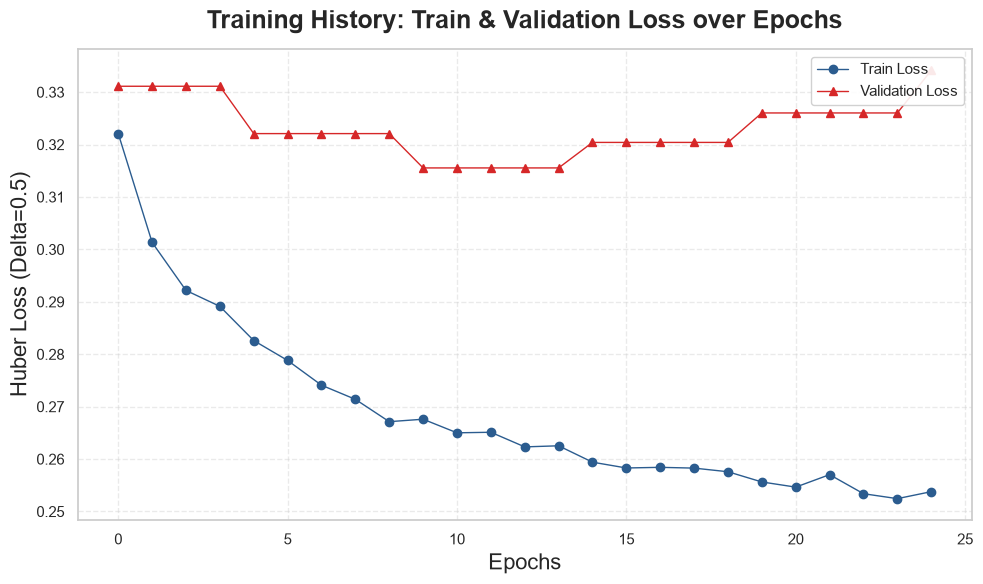

In [373]:
# Visualize the training history (Train & Validation Loss) over epochs

history = model_training_results['history']

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='#2b5c8f', linewidth=1, marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='#d62728', linewidth=1, marker='^')
plt.title("Training History: Train & Validation Loss over Epochs", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Huber Loss (Delta=0.5)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig(base_model_plots_dir / "01_Base_Train_Val_Loss_History.png", dpi=300, bbox_inches='tight')
plt.show()

In [374]:
# Evaluate the model on the validation set and export predictions

def evaluate_and_export(
    model,
    dataloader,
    preprocessor,
    device="cuda",
    save_parquet_path="eval_predictions.parquet",
):
    # Set the model to evaluation mode and move it to the GPU
    model.eval()
    model.to(device)

    # Lookup column indices
    idx_year = preprocessor.get_col_idx("Year", "cat")
    idx_event = preprocessor.get_col_idx("Event", "cat")
    idx_driver = preprocessor.get_col_idx("Driver", "cat")
    idx_lap = preprocessor.get_col_idx("LapNumber", "cont")
    idx_lap_time = preprocessor.get_col_idx("LapTimeSeconds", "cont")

    all_records = []
    all_pred_scaled = []
    all_true_scaled = []
    global_sample_id = 0

    with torch.no_grad():
        # Loop through the DataLoader and process each batch
        for x_cat, x_cont, x_cat_fut, x_cont_fut, y_target in dataloader:
            x_cat_dev = x_cat.to(device, non_blocking=True)
            x_cont_dev = x_cont.to(device, non_blocking=True)
            x_cat_fut_dev = x_cat_fut.to(device, non_blocking=True)
            x_cont_fut_dev = x_cont_fut.to(device, non_blocking=True)

            # Make predictions and move them back to CPU for further processing
            preds = model(
                x_cat_dev, x_cont_dev, x_cat_fut_dev, x_cont_fut_dev, y_target=None
            )

            preds_np = preds.cpu().numpy().squeeze(-1)
            targets_np = y_target.numpy().squeeze(-1)

            all_pred_scaled.append(preds_np)
            all_true_scaled.append(targets_np)

            batch_size, seq_len, _ = x_cont.shape
            forecast_len = preds_np.shape[1]

            # Extract metadata for each sample in the batch 
            # and inverse transform categorical features
            years = preprocessor.inverse_transform_cat("Year", x_cat[:, -1, idx_year])
            events = preprocessor.inverse_transform_cat("Event", x_cat[:, -1, idx_event])
            drivers = preprocessor.inverse_transform_cat("Driver", x_cat[:, -1, idx_driver])

            for b in range(batch_size):
                # Historical sequence
                hist_laps = np.round(
                    preprocessor.inverse_transform_cont(
                        x_cont[b, :, idx_lap].numpy(), "LapNumber"
                    )
                ).astype(int)
                hist_times = preprocessor.inverse_transform_cont(
                    x_cont[b, :, idx_lap_time].numpy(), "LapTimeSeconds"
                )

                # Future predictions and true values
                sample_pred_deltas = preprocessor.inverse_transform_cont(
                    preds_np[b], "LapTimeDelta"
                )
                sample_true_deltas = preprocessor.inverse_transform_cont(
                    targets_np[b], "LapTimeDelta"
                )

                anchor_time = float(hist_times[-1])
                anchor_lap = int(hist_laps[-1])

                pred_times = anchor_time + np.cumsum(sample_pred_deltas)
                true_times = anchor_time + np.cumsum(sample_true_deltas)

                # Target lap numbers (including anchor lap at index 0 for plotting continuity)
                target_laps = [anchor_lap] + [
                    anchor_lap + step + 1 for step in range(forecast_len)
                ]

                # ONE DICT PER SAMPLE
                all_records.append(
                    {   
                        # Meta
                        "Year": int(years[b]),
                        "Event": events[b],
                        "Driver": drivers[b],
                        "Sample_ID": global_sample_id,
                        # Lap numbers
                        "Hist_Laps": hist_laps.tolist(),
                        "Anchor_Lap": anchor_lap,
                        "Target_Laps": target_laps,
                        # Lap times
                        "Hist_Times": hist_times.tolist(),
                        "True_Times": [anchor_time] + true_times.tolist(),
                        "Pred_Times": [anchor_time] + pred_times.tolist(),
                        # Deltas
                        "Pred_Delta": sample_pred_deltas,
                        "True_Delta":sample_true_deltas
                    }
                )
                global_sample_id += 1

    # Save to Parquet
    export_df = pd.DataFrame(all_records)
    if save_parquet_path:
        export_df.to_parquet(save_parquet_path, index=False)
        print(f"Results successfully saved to {save_parquet_path}")

    # Global Diagnostics (MAE / RMSE / Residuals)
    pred_scaled_all = np.vstack(all_pred_scaled)
    true_scaled_all = np.vstack(all_true_scaled)
    _, forecast_len = pred_scaled_all.shape

    # 1. Pre-allocate arrays
    pred_unscaled = np.zeros_like(pred_scaled_all)
    true_unscaled = np.zeros_like(true_scaled_all)

    # 2. Invert scaling for each forecast horizon step
    for step in range(forecast_len):
      pred_unscaled[:, step] = preprocessor.inverse_transform_cont(
          pred_scaled_all[:, step], "LapTimeDelta"
      )
      true_unscaled[:, step] = preprocessor.inverse_transform_cont(
          true_scaled_all[:, step], "LapTimeDelta"
      )

    # 3. Calculate cumulative time steps (accumulating lap delta errors)
    pred_cum_times = np.cumsum(pred_unscaled, axis=1)
    true_cum_times = np.cumsum(true_unscaled, axis=1)

    # 4. Evaluate MAE/RMSE over horizon steps on cumulative times
    horizon_metrics = []
    for step in range(forecast_len):
      step_p = pred_cum_times[:, step]  # Cumulative predicted change by step k
      step_t = true_cum_times[:, step]  # Cumulative true change by step k

      horizon_metrics.append({
          "Horizon_Step": f"+{step+1} Lap",
          "MAE": np.mean(np.abs(step_t - step_p)),
          "RMSE": np.sqrt(np.mean((step_t - step_p) ** 2)),
      })

    horizon_df = pd.DataFrame(horizon_metrics)

    # 5. Residual Analysis on cumulative lap errors across all horizon steps
    cum_residuals = true_cum_times - pred_cum_times
    flat_res = cum_residuals.flatten()
    q25, q75 = np.percentile(flat_res, [25, 75])

    residual_stats = {
        "Total_Predictions": len(flat_res),
        "Mean_Error": np.mean(flat_res),
        "Std_Dev": np.std(flat_res),
        "Median_Error": np.median(flat_res),
        "IQR_25": q25,
        "IQR_75": q75,
        "Outliers_Gt_5s": np.sum(np.abs(flat_res) > 5.0),
    }

    return {
        "export_df": export_df,
        "horizon_df": horizon_df,
        "residual_stats": residual_stats,
        "residual": flat_res
    }

base_model = model_training_results["model"]

base_model_eval_val = evaluate_and_export(
                            model=base_model,
                            dataloader=val_loader,
                            preprocessor=preprocessor,
                            device="cuda",
                            save_parquet_path=results_dir / "base_val_predictions.parquet",
                        )

Results successfully saved to results\base_val_predictions.parquet


Random Samples plot saved to plots\Base_Model\02_Base_Val_Random_Samples_Predictions.png


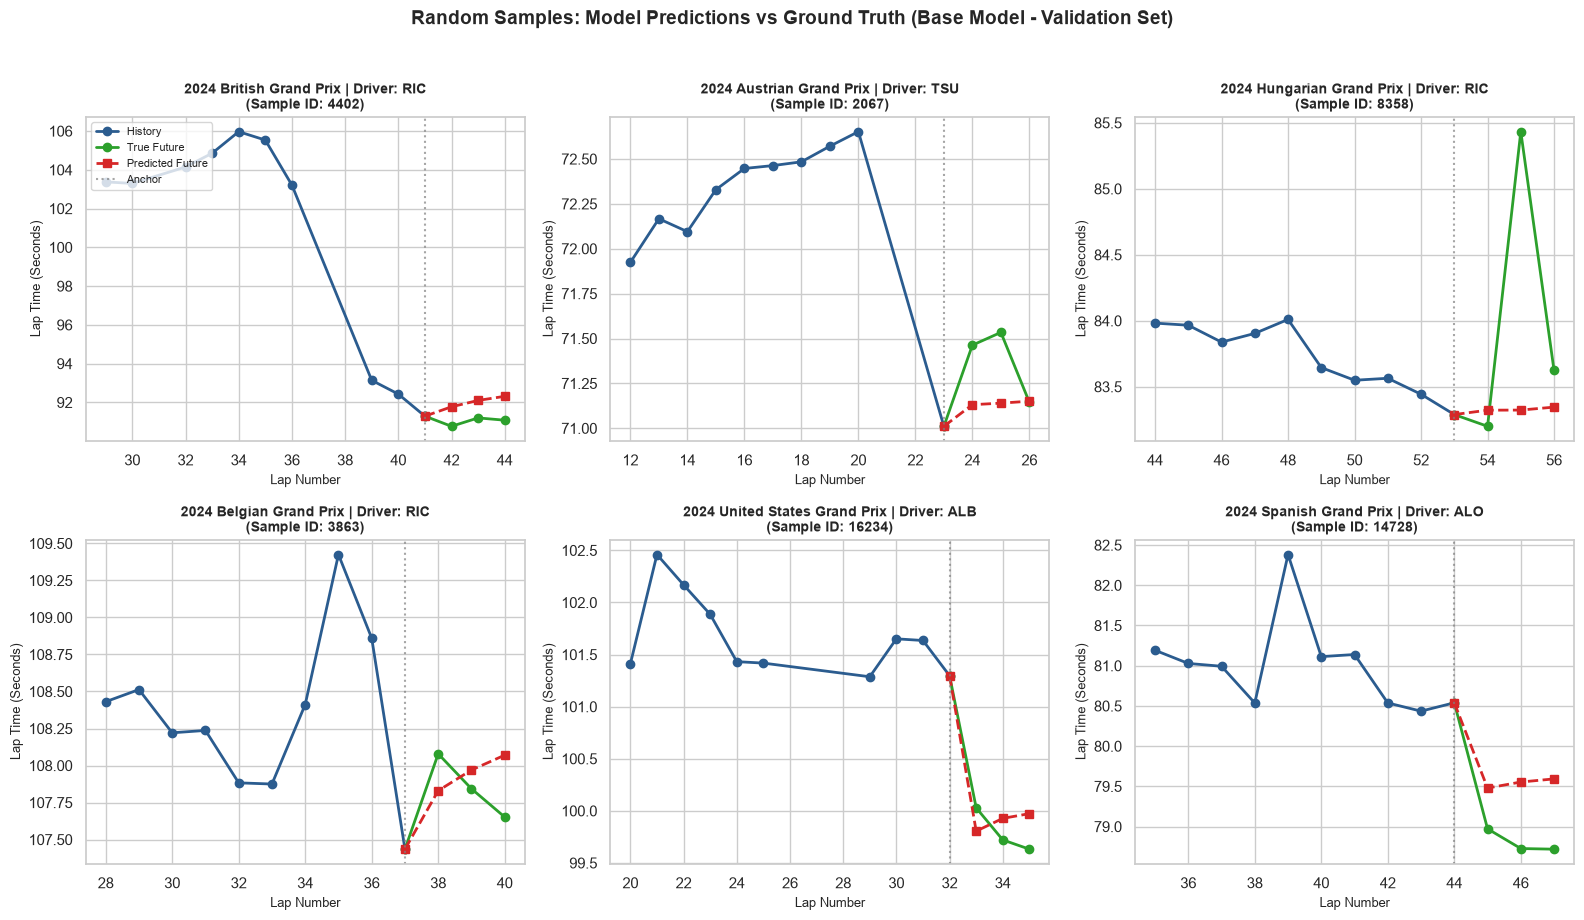

In [375]:
# Visualize Random Samples of Predictions vs Ground Truth

def plot_random_samples(df_or_records, title, savepath, num_samples=6, seed=None, ):
    """Plots a grid of randomly sampled lap time predictions vs ground truth.

    Parameters:
    -----------
    df_or_records : pd.DataFrame or list of dicts
        The export DataFrame or list containing evaluation records.
    num_samples : int, optional (default=6)
        Number of samples to plot (default is 6 for a 2x3 grid).
    seed : int, optional
        Random seed for reproducible sampling.
    """
    if seed is not None:
        random.seed(seed)

    # Convert list of dicts to DataFrame if needed
    df = (
        pd.DataFrame(df_or_records)
        if isinstance(df_or_records, list)
        else df_or_records.copy()
    )

    # Sample randomly
    sample_indices = random.sample(range(len(df)), min(num_samples, len(df)))
    sampled_df = df.iloc[sample_indices]

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
    axes = axes.flatten()

    for idx, (_, row) in enumerate(sampled_df.iterrows()):
        ax = axes[idx]

        # Extract sequence series
        hist_laps = row["Hist_Laps"]
        hist_times = row["Hist_Times"]

        # Target_Laps already includes the anchor lap at index 0
        target_laps = row["Target_Laps"]
        true_times = row["True_Times"]
        pred_times = row["Pred_Times"]

        # Plot Historical Laps
        ax.plot(
            hist_laps,
            hist_times,
            color="#2b5c8f",
            marker="o",
            linewidth=2,
            label="History",
        )

        # Plot True Future Laps
        ax.plot(
            target_laps,
            true_times,
            color="#2ca02c",
            marker="o",
            linestyle="-",
            linewidth=2,
            label="True Future",
        )

        # Plot Predicted Future Laps
        ax.plot(
            target_laps,
            pred_times,
            color="#d62728",
            marker="s",
            linestyle="--",
            linewidth=2,
            label="Predicted Future",
        )

        # Draw a subtle vertical anchor line separating History and Forecast Horizon
        anchor_lap = row["Anchor_Lap"]
        ax.axvline(
            x=anchor_lap, color="gray", linestyle=":", alpha=0.7, label="Anchor"
        )

        # Subplot Title & Labels
        ax.set_title(
            f"{row['Year']} {row['Event']} | Driver: {row['Driver']}\n(Sample ID: {row['Sample_ID']})",
            fontsize=10,
            fontweight="bold",
        )
        ax.set_xlabel("Lap Number", fontsize=9)
        ax.set_ylabel("Lap Time (Seconds)", fontsize=9)

        # Add legend only on the first plot to avoid visual clutter
        if idx == 0:
            ax.legend(loc="upper left", fontsize=8)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02,)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Random Samples plot saved to {savepath}")
    plt.show() 

plot_random_samples(
    df_or_records=base_model_eval_val["export_df"],
    title="Random Samples: Model Predictions vs Ground Truth (Base Model - Validation Set)",
    savepath=base_model_plots_dir / "02_Base_Val_Random_Samples_Predictions.png",
    num_samples=6,
    seed=1,
)

Forecast Horizon Error Decay plot saved to plots\Base_Model\02_Base_Val_Forecast_Horizon_Error_Decay.png


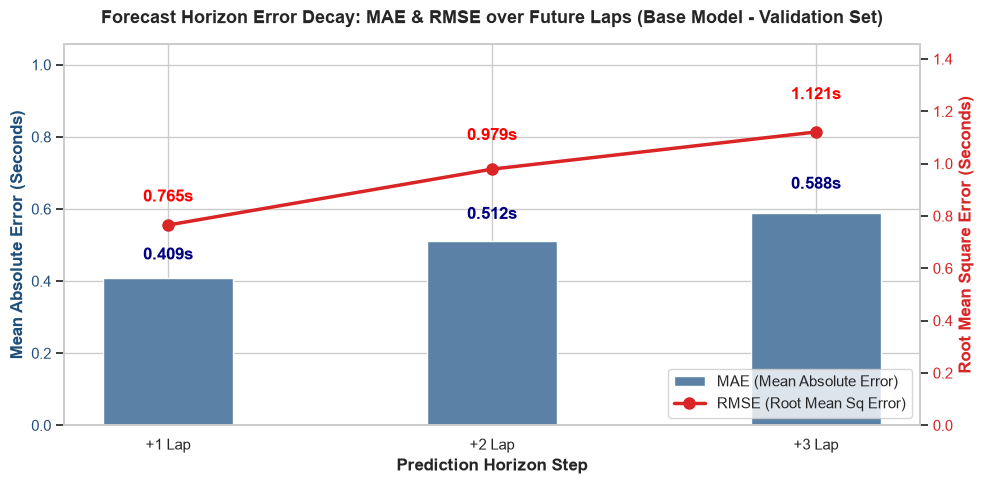

In [376]:
# Visualize the Forecast Horizon Error Decay (MAE & RMSE) 

def plot_forecast_horizon_errors(horizon_df, title, savepath=None):
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot MAE (Bar Chart on Primary Y-Axis)
    x_labels = [f"+{i+1} Lap" for i in range(len(horizon_df))]
    x_indices = np.arange(len(x_labels))
    bars = ax1.bar(
        x_indices,
        horizon_df["MAE"],
        color="#5b82a6",
        width=0.4,
        label="MAE (Mean Absolute Error)",
    )

    ax1.set_xlabel("Prediction Horizon Step", fontweight="bold")
    ax1.set_ylabel("Mean Absolute Error (Seconds)", color="#1f4e79", fontweight="bold")
    ax1.tick_params(axis="y", labelcolor="#1f4e79")
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_labels)
    ax1.set_ylim(0, max(horizon_df["MAE"]) * 1.8)

    # Add values above bars
    for bar in bars:
        yval = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval * 1.1,
            f"{yval:.3f}s",
            ha="center",
            va="bottom",
            fontweight="bold",
            color = "navy",
        )

    # Plot RMSE (Line Chart on Secondary Y-Axis)
    ax2 = ax1.twinx()
    line = ax2.plot(
        x_indices,
        horizon_df["RMSE"],
        color="#d92525",
        marker="o",
        linewidth=2.5,
        markersize=8,
        label="RMSE (Root Mean Sq Error)",
    )

    # Add values above points
    for i, yval in enumerate(horizon_df["RMSE"]):
        ax2.text(
            x_indices[i],
            yval * 1.1,
            f"{yval:.3f}s",
            ha="center",
            va="bottom",
            fontweight="bold",
            color = "red",
        )

    ax2.set_ylabel("Root Mean Square Error (Seconds)", color="#d92525", fontweight="bold")
    ax2.tick_params(axis="y", labelcolor="#d92525")
    ax2.set_ylim(0, max(horizon_df["RMSE"]) * 1.3)
    ax2.grid(False)

    # Combined Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right")

    plt.title(title, fontsize=13, fontweight="bold", pad=15,)
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Forecast Horizon Error Decay plot saved to {savepath}")
    plt.tight_layout()
    plt.show()

horizon_df = base_model_eval_val["horizon_df"]
plot_forecast_horizon_errors(
    horizon_df,
    title="Forecast Horizon Error Decay: MAE & RMSE over Future Laps (Base Model - Validation Set)",
    savepath=base_model_plots_dir / "02_Base_Val_Forecast_Horizon_Error_Decay.png"
)


Residual Distribution plot saved to plots\Base_Model\04_Base_Val_Residual_Distribution.png


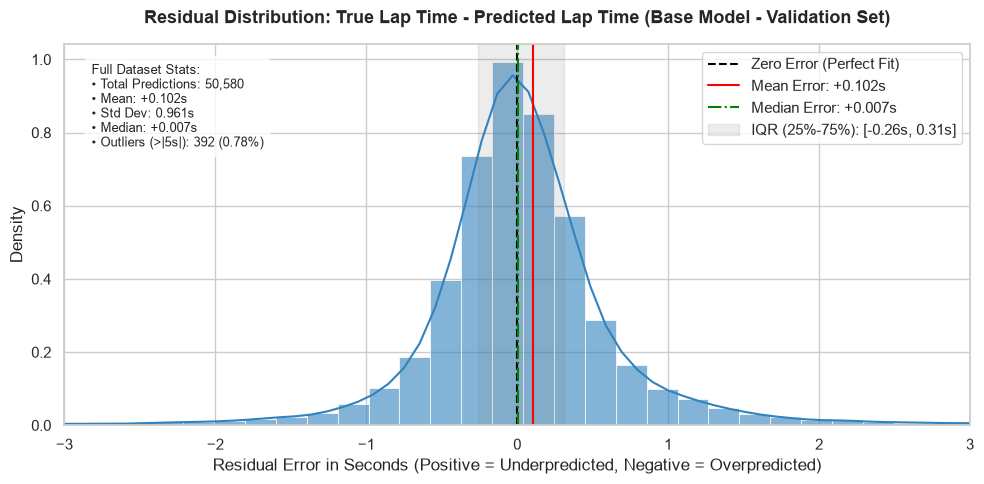

In [377]:
# Visualize the Error Residual Distribution (True - Pred)

def plot_residual_distribution(residuals, stats, title, xlim=None, savepath=None):
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.histplot(
        residuals,
        kde=True,
        stat="density",
        color="#3182bd",
        bins=100,
        ax=ax,
        alpha=0.6,
    )

    # Reference vertical lines
    plt.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Zero Error (Perfect Fit)",
    )
    plt.axvline(
        stats["Mean_Error"],
        color="red",
        linestyle="-",
        linewidth=1.5,
        label=f"Mean Error: {stats['Mean_Error']:+.3f}s",
    )
    plt.axvline(
        stats["Median_Error"],
        color="green",
        linestyle="-.",
        linewidth=1.5,
        label=f"Median Error: {stats['Median_Error']:+.3f}s",
    )

    # IQR Shading
    ax.axvspan(
        stats["IQR_25"],
        stats["IQR_75"],
        color="gray",
        alpha=0.15,
        label=f"IQR (25%-75%): [{stats['IQR_25']:.2f}s, {stats['IQR_75']:.2f}s]",
    )

    # Text Box with Summary Stats
    outlier_pct = (stats["Outliers_Gt_5s"] / stats["Total_Predictions"]) * 100
    stats_text = (
        f"Full Dataset Stats:\n"
        f"• Total Predictions: {stats['Total_Predictions']:,}\n"
        f"• Mean: {stats['Mean_Error']:+.3f}s\n"
        f"• Std Dev: {stats['Std_Dev']:.3f}s\n"
        f"• Median: {stats['Median_Error']:+.3f}s\n"
        f"• Outliers (>|5s|): {stats['Outliers_Gt_5s']} ({outlier_pct:.2f}%)"
    )

    ax.text(
        0.03,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8),
    )

    if xlim:
        plt.xlim(xlim)
    plt.xlabel( "Residual Error in Seconds (Positive = Underpredicted, Negative = Overpredicted)")
    plt.ylabel("Density")
    plt.title(title, fontsize=13, fontweight="bold", pad=15)
    plt.legend(loc="upper right")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Residual Distribution plot saved to {savepath}")
    plt.show()

residuals = base_model_eval_val["residual"]
stats = base_model_eval_val["residual_stats"]

plot_residual_distribution(
    residuals,
    stats,
    title="Residual Distribution: True Lap Time - Predicted Lap Time (Base Model - Validation Set)",
    savepath=base_model_plots_dir / "04_Base_Val_Residual_Distribution.png",
    xlim=(-3,3)
)

# Tuning the LSTM model (using Optuna)

In [311]:
# Define the Optuna objective function for hyperparameter optimization with a two-stage coarse-to-fine search strategy

def objective(trial, stage=1, best_params_stage1=None, epochs=50):
    # -------------------------------------------------------------------------
    # 1. Coarse-to-Fine Search Space
    # -------------------------------------------------------------------------
    if stage == 1:
        # Tune core architecture parameters in Stage 1
        hidden_dim    = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
        embed_dim     = trial.suggest_int("embed_dim", 2, 8, step=2)
        num_layers    = trial.suggest_int("num_layers", 1, 3)
        learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)

        # Mild baseline regularization for Stage 1 (lets models learn)
        dropout = 0.2
        weight_decay = 1e-4  # Lowered from 0.01 to prevent suppressing larger architectures
        HuberLoss_delta = 1.0

    elif stage == 2:
        if best_params_stage1 is None:
            raise ValueError("best_params_stage1 must be provided for stage 2.")

        # Freeze Stage 1 best architecture
        hidden_dim = best_params_stage1["hidden_dim"]
        embed_dim  = best_params_stage1["embed_dim"]
        num_layers = best_params_stage1["num_layers"]

        # Fine-tune regularization and loss dynamics
        lr_stage_1      = best_params_stage1["learning_rate"]
        learning_rate   = trial.suggest_float("learning_rate", lr_stage_1 * 0.2, lr_stage_1 * 2.0, log=True)
        dropout         = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
        weight_decay    = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        HuberLoss_delta = trial.suggest_float("HuberLoss_delta", 0.3, 2.0)

    # Fixed training parameters
    sche_patience = 5               # Patience for ReduceLROnPlateau scheduler
    early_stopping_patience = 12    # Patience for early stopping
    noise_std = 0.02                

    # -------------------------------------------------------------------------
    # 2. Setup Model, Loss, Optimizer, and Scheduler
    # -------------------------------------------------------------------------
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model = F1LapSeq2Seq(
        cat_dims=cat_dims, 
        cont_dim=cont_dim, 
        hidden_dim=hidden_dim, 
        embed_dim=embed_dim, 
        forecast_len=forecast_len,
        num_layers=num_layers,
        dropout=dropout,
        target_cont_idx=target_cont_idx
    ).to(device)

    criterion = nn.HuberLoss(delta=HuberLoss_delta)                                                                                                                
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                                 
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=sche_patience, factor=0.6) 

    # -------------------------------------------------------------------------
    # 3. Training Loop with Pruning & Early Stopping
    # -------------------------------------------------------------------------
    best_val_loss = float('inf')
    counter = 0

    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        model.train()
        tf_ratio = max(0.2, 1.0 - (epoch / (epochs * 0.8)))

        for data in train_loader:
            x_cat, x_cont, x_cat_fut, x_cont_fut, y_target = data
            x_cat = x_cat.to(device, non_blocking=True)
            x_cont = x_cont.to(device, non_blocking=True)
            x_cat_fut = x_cat_fut.to(device, non_blocking=True)
            x_cont_fut = x_cont_fut.to(device, non_blocking=True)
            y_target = y_target.to(device, non_blocking=True)

            optimizer.zero_grad()

            # 1. Forward pass under autocast
            with torch.amp.autocast('cuda'):
                predictions = model(
                    x_cat,
                    x_cont,
                    x_cat_fut,
                    x_cont_fut,
                    y_target=y_target,
                    teacher_forcing_ratio=tf_ratio,
                    noise_std=noise_std,
                )
                loss = criterion(predictions, y_target)

            # 2. Scaled backward pass
            scaler.scale(loss).backward()

            # 3. Unscale gradients before clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # 4. Step optimizer and update scale
            scaler.step(optimizer)
            scaler.update()

        # Validation Step
        val_loss = validate(model, val_loader, criterion, device)
        
        # Report metric to Optuna for automatic pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # LR Scheduler step
        scheduler.step(val_loss)
        
        # Early Stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0  
        else:
            counter += 1

        if counter >= early_stopping_patience:
            break

    return best_val_loss



In [312]:
# Stage 1: Coarse Search

# Define the Optuna pruner
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)

print("Starting Stage 1 Optimization...")
study_stage1 = optuna.create_study(direction="minimize", pruner=pruner)
study_stage1.optimize(
    lambda trial: objective(trial, stage=1, epochs=30),
    n_trials=20
) 

print("\nStage 1 Best Parameters:", study_stage1.best_params)


[I 2026-08-18 03:45:21,213] A new study created in memory with name: no-name-999b9090-7c99-4df7-adb2-6ccd117c903b


Starting Stage 1 Optimization...


[I 2026-08-18 03:46:05,383] Trial 0 finished with value: 0.5003899931907654 and parameters: {'hidden_dim': 128, 'embed_dim': 4, 'num_layers': 2, 'learning_rate': 0.00266506427398249}. Best is trial 0 with value: 0.5003899931907654.
[I 2026-08-18 03:46:35,189] Trial 1 finished with value: 0.5423410534858704 and parameters: {'hidden_dim': 128, 'embed_dim': 8, 'num_layers': 1, 'learning_rate': 0.00010334765110113011}. Best is trial 0 with value: 0.5003899931907654.
[I 2026-08-18 03:47:21,804] Trial 2 finished with value: 0.5320790410041809 and parameters: {'hidden_dim': 32, 'embed_dim': 6, 'num_layers': 2, 'learning_rate': 0.0009522152478725153}. Best is trial 0 with value: 0.5003899931907654.
[I 2026-08-18 03:48:34,280] Trial 3 finished with value: 0.5213575959205627 and parameters: {'hidden_dim': 32, 'embed_dim': 4, 'num_layers': 2, 'learning_rate': 0.00016578191292517775}. Best is trial 0 with value: 0.5003899931907654.
[I 2026-08-18 03:49:10,612] Trial 4 finished with value: 0.5046689


Stage 1 Best Parameters: {'hidden_dim': 64, 'embed_dim': 2, 'num_layers': 2, 'learning_rate': 0.000744263274757177}


In [314]:
# Stage 2: Fine Search

print("\nStarting Stage 2 Optimization...")
study_stage2 = optuna.create_study(direction="minimize", pruner=pruner)
study_stage2.optimize(
    lambda trial: objective(trial, stage=2, best_params_stage1=study_stage1.best_params, epochs=50),
    n_trials=20
)

print("\nStage 2 Best Parameters:", study_stage2.best_params)


[I 2026-08-18 05:43:38,628] A new study created in memory with name: no-name-09a87c90-2f25-4075-bec0-ca88e7ad81a8



Starting Stage 2 Optimization...


[I 2026-08-18 05:45:09,655] Trial 0 finished with value: 0.5290722846984863 and parameters: {'learning_rate': 0.00040746440356491994, 'dropout': 0.30000000000000004, 'weight_decay': 0.0012210657905231896, 'HuberLoss_delta': 1.073662611320902}. Best is trial 0 with value: 0.5290722846984863.
[I 2026-08-18 05:47:35,698] Trial 1 finished with value: 0.5749980807304382 and parameters: {'learning_rate': 0.00018977378142928582, 'dropout': 0.30000000000000004, 'weight_decay': 4.26291263303821e-05, 'HuberLoss_delta': 1.225615358877391}. Best is trial 0 with value: 0.5290722846984863.
[I 2026-08-18 05:50:04,076] Trial 2 finished with value: 0.6762987375259399 and parameters: {'learning_rate': 0.00020030525168562093, 'dropout': 0.4, 'weight_decay': 8.488387381978719e-05, 'HuberLoss_delta': 1.750743806876234}. Best is trial 0 with value: 0.5290722846984863.
[I 2026-08-18 05:52:48,109] Trial 3 finished with value: 0.7186949253082275 and parameters: {'learning_rate': 0.00017407478405432488, 'dropou


Stage 2 Best Parameters: {'learning_rate': 0.0009660449164345999, 'dropout': 0.5, 'weight_decay': 0.009473167478706064, 'HuberLoss_delta': 0.30177983062459784}


In [317]:
# Final Model Training with Combined Best Parameters

# Merge Stage 1 and Stage 2 best parameters for final model configuration
best_params = {**study_stage1.best_params, **study_stage2.best_params}
print("\nCombined Optimal Hyperparameters:", best_params)


# Define the model with the best hyperparameters found from the Optuna optimization
best_model = F1LapSeq2Seq(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    hidden_dim=best_params.get("hidden_dim", 32), 
    embed_dim=best_params.get("embed_dim", 4),
    forecast_len=forecast_len,
    num_layers=best_params.get("num_layers", 2),
    dropout=best_params.get("dropout", 0.5),
    target_cont_idx=target_cont_idx
)

# # Train the model with the best training parameters
best_model_training_results = train_f1_model(
    # Model and DataLoaders
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    noise_std=0.02, 
    epochs=150,
    # Training Hyperparameters from Optuna
    HuberLoss_delta=best_params.get("HuberLoss_delta", 1.0),
    learning_rate=best_params.get("learning_rate", 0.0001),
    weight_decay=best_params.get("weight_decay", 0.02),
    # Scheduler and Early Stopping
    sche_patience=10,
    sche_factor=0.5,
    early_stopping_chance=5,
    # Model Saving Path
    model_save_path='./models/best_model.pth'
)


Combined Optimal Hyperparameters: {'hidden_dim': 64, 'embed_dim': 2, 'num_layers': 2, 'learning_rate': 0.0009660449164345999, 'dropout': 0.5, 'weight_decay': 0.009473167478706064, 'HuberLoss_delta': 0.30177983062459784}
Starting training on device: cuda
--------------------------------------------------
Epoch [01/150] | Train Loss: 0.2186 | Val Loss: 0.2217 | TF ratio: 0.80 |LR: 0.000966 --> [Model Saved]
Epoch [02/150] | Train Loss: 0.2045 | Val Loss: 0.2217 | TF ratio: 0.79 |LR: 0.000966 (Skipped Val)
Epoch [03/150] | Train Loss: 0.2003 | Val Loss: 0.2217 | TF ratio: 0.78 |LR: 0.000966 (Skipped Val)
Epoch [04/150] | Train Loss: 0.1990 | Val Loss: 0.2217 | TF ratio: 0.78 |LR: 0.000966 (Skipped Val)
Epoch [05/150] | Train Loss: 0.1965 | Val Loss: 0.2173 | TF ratio: 0.77 |LR: 0.000966 --> [Model Saved]
Epoch [06/150] | Train Loss: 0.1924 | Val Loss: 0.2173 | TF ratio: 0.76 |LR: 0.000966 (Skipped Val)
Epoch [07/150] | Train Loss: 0.1903 | Val Loss: 0.2173 | TF ratio: 0.75 |LR: 0.000966 

# Evaluate the Best Model

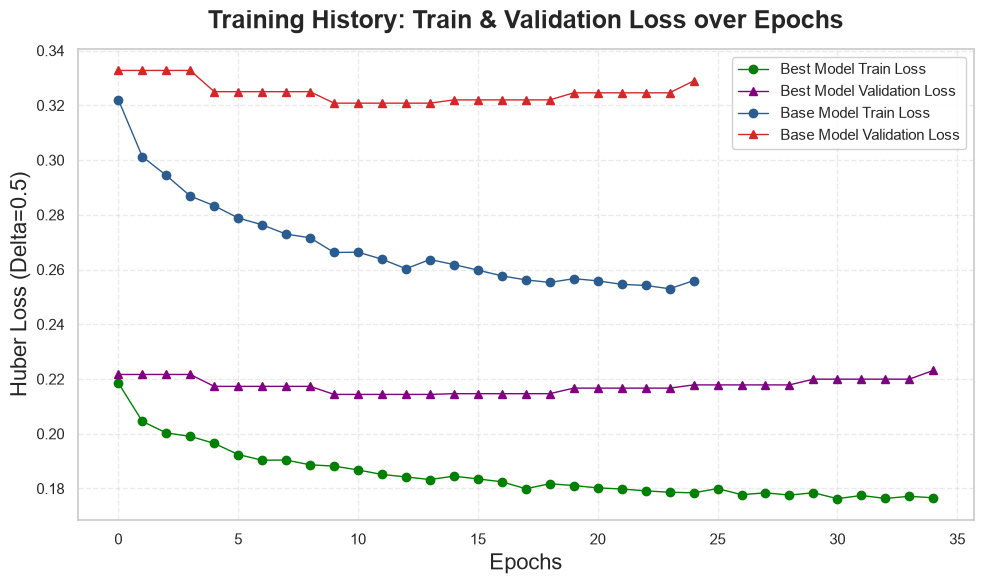

In [320]:
# Visualize the training history (Train & Validation Loss) over epochs

history_best = best_model_training_results['history']

plt.figure(figsize=(10, 6))

# plot the training history of the best model
plt.plot(history_best['train_loss'], label='Best Model Train Loss', color='green', linewidth=1, marker='o')
plt.plot(history_best['val_loss'], label='Best Model Validation Loss', color='purple', linewidth=1, marker='^')

# plot the training history of the base model
plt.plot(history['train_loss'], label='Base Model Train Loss', color='#2b5c8f', linewidth=1, marker='o')
plt.plot(history['val_loss'], label='Base Model Validation Loss', color='#d62728', linewidth=1, marker='^')

plt.title("Training History: Train & Validation Loss over Epochs", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Huber Loss (Delta=0.5)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig(best_model_plots_dir / "01_Best_Train_Val_Loss_History.png", dpi=300, bbox_inches='tight')
plt.show()

In [321]:
# Evaluate the model on Validation set and Test set
best_model = best_model_training_results["model"]

best_model_eval_val = evaluate_and_export(
                            model=best_model,
                            dataloader=val_loader,
                            preprocessor=preprocessor,
                            device="cuda",
                            save_parquet_path=results_dir / "best_val_predictions.parquet",
                        )


best_model_eval_test = evaluate_and_export(
                            model=best_model,
                            dataloader=test_loader,
                            preprocessor=preprocessor,
                            device="cuda",
                            save_parquet_path=results_dir / "best_test_predictions.parquet",
                        )

Results successfully saved to results\best_val_predictions.parquet
Results successfully saved to results\best_test_predictions.parquet


Random Samples plot saved to plots\Best_Model\02_Best_Val_Random_Samples_Predictions.png


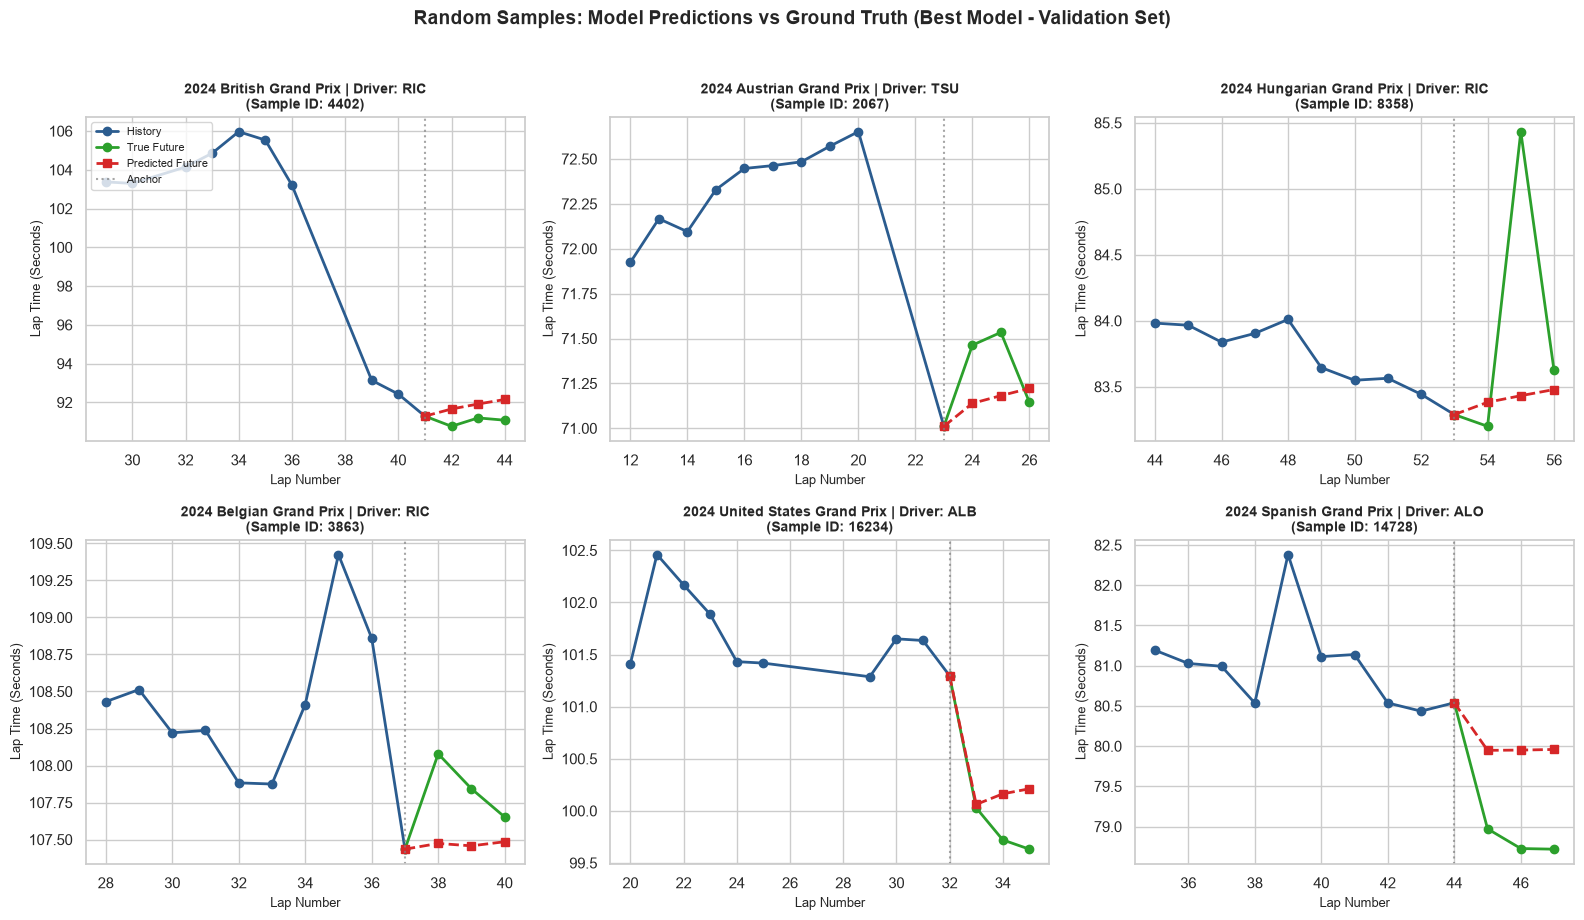

Random Samples plot saved to plots\Best_Model\03_Best_Test_Random_Samples_Predictions.png


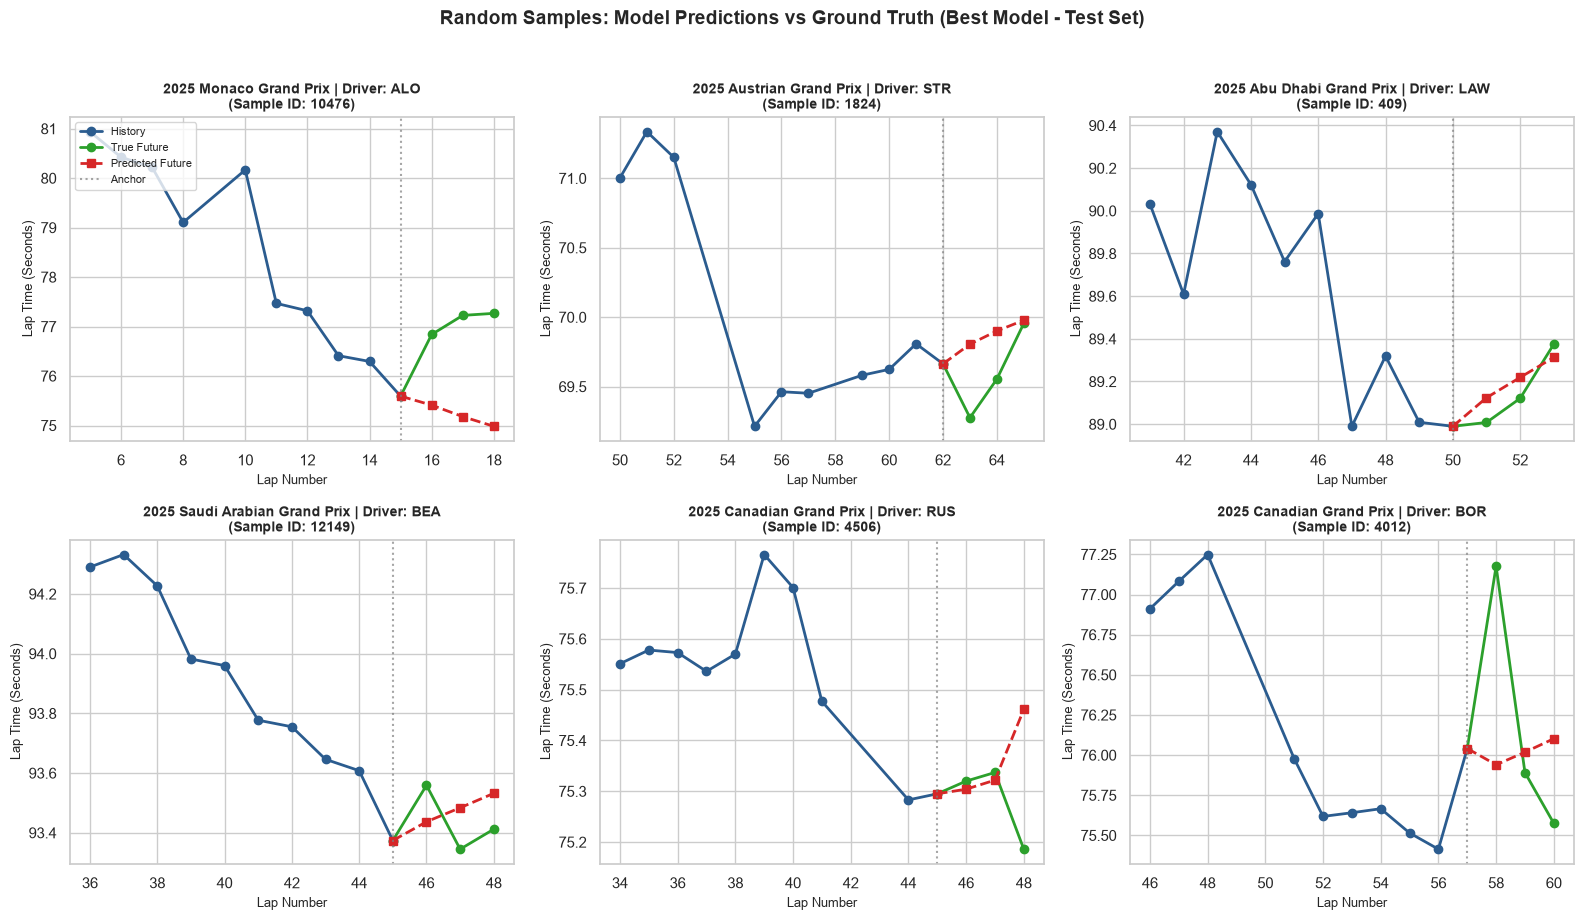

In [329]:
# Visualize Random Samples of Predictions vs Ground Truth

plot_random_samples(
    df_or_records=best_model_eval_val["export_df"],
    title="Random Samples: Model Predictions vs Ground Truth (Best Model - Validation Set)",
    savepath=best_model_plots_dir / "02_Best_Val_Random_Samples_Predictions.png",
    num_samples=6,
    seed=1,
)

plot_random_samples(
    df_or_records=best_model_eval_test["export_df"],
    title="Random Samples: Model Predictions vs Ground Truth (Best Model - Test Set)",
    savepath=best_model_plots_dir / "03_Best_Test_Random_Samples_Predictions.png",
    num_samples=6,
    seed=42,
)

Forecast Horizon Error Decay plot saved to plots\Best_Model\04_Best__Val_Forecast_Horizon_Error_Decay.png


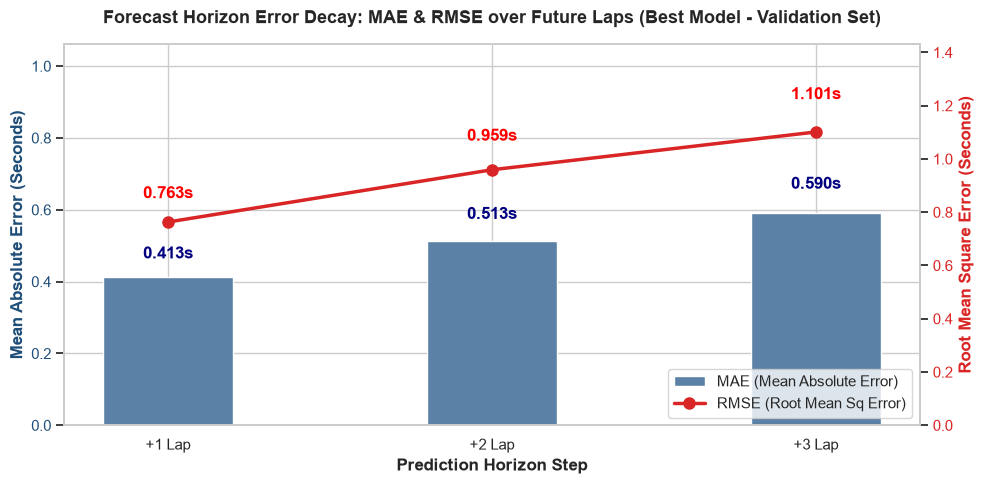

Forecast Horizon Error Decay plot saved to plots\Best_Model\05_Best_Test_Forecast_Horizon_Error_Decay.png


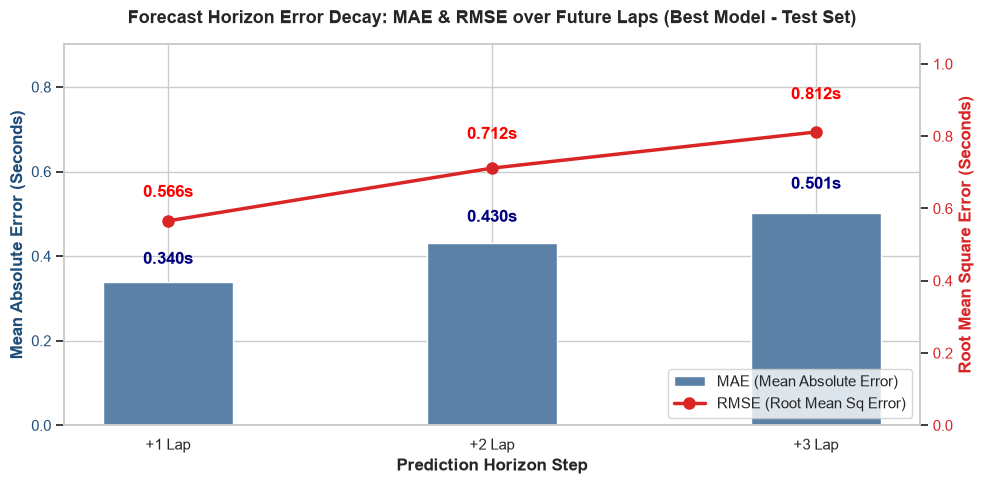

In [333]:
# Visualize the Forecast Horizon Error Decay (MAE & RMSE) 

horizon_df_best_val = best_model_eval_val["horizon_df"]

plot_forecast_horizon_errors(
    horizon_df_best_val,
    title="Forecast Horizon Error Decay: MAE & RMSE over Future Laps (Best Model - Validation Set)",
    savepath=best_model_plots_dir / "04_Best__Val_Forecast_Horizon_Error_Decay.png"
)

horizon_df_best_test = best_model_eval_test["horizon_df"]

plot_forecast_horizon_errors(
    horizon_df_best_test,
    title="Forecast Horizon Error Decay: MAE & RMSE over Future Laps (Best Model - Test Set)",
    savepath=best_model_plots_dir / "05_Best_Test_Forecast_Horizon_Error_Decay.png"
)

Residual Distribution plot saved to plots\Best_Model\06_Best_Val_Residual_Distribution.png


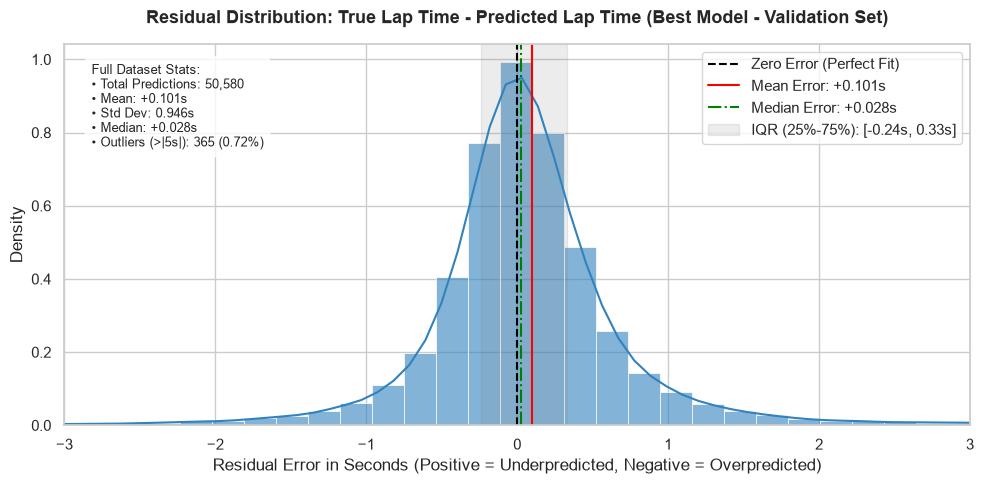

Residual Distribution plot saved to plots\Best_Model\07_Best_Test_Residual_Distribution.png


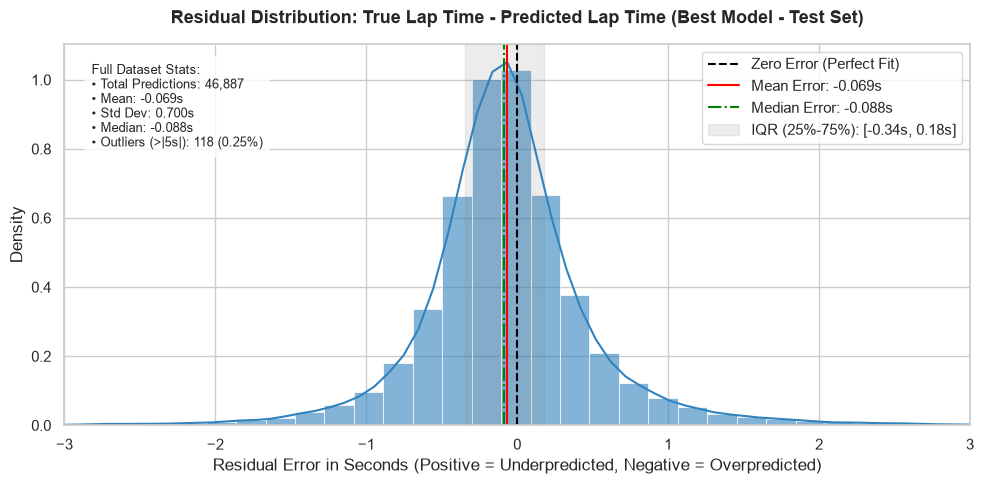

In [334]:
# Visualize the Error Residual Distribution (True - Pred)

residuals_best_val = best_model_eval_val["residual"]
stats_best_val     = best_model_eval_val["residual_stats"]

plot_residual_distribution(
    residuals_best_val,
    stats_best_val,
    title="Residual Distribution: True Lap Time - Predicted Lap Time (Best Model - Validation Set)",
    savepath=best_model_plots_dir / "06_Best_Val_Residual_Distribution.png",
    xlim=(-3,3)
)

residuals_best_test = best_model_eval_test["residual"]
stats_best_test     = best_model_eval_test["residual_stats"]

plot_residual_distribution(
    residuals_best_test,
    stats_best_test,
    title="Residual Distribution: True Lap Time - Predicted Lap Time (Best Model - Test Set)",
    savepath=best_model_plots_dir / "07_Best_Test_Residual_Distribution.png",
    xlim=(-3,3)
)

In [ ]:
# print the original hyperparameters and the best hyperparameters found from the Optuna optimization

base_model_val_loss = model_training_results['best_val_loss']
best_model_val_loss = best_model_training_results['best_val_loss']

print("\n" + "="*60)
print(f"Base Model Validation Loss: {base_model_val_loss:.4f}")
print(f"Best Model Validation Loss: {best_model_val_loss:.4f}")


Base Model Validation Loss: 0.2984
Best Model Validation Loss: 0.2832


# Permutation Importance of Features

In [ ]:
# Calculate the permutation importance of features

def calculate_permutation_importance_strict(
    model,
    dataset,
    cat_idx,
    cont_idx,
    target_cont_idx,
    unknown_cont_rel_idx,
    feature_names_map,
    device="cuda",
    batch_size=512,
):
  model.to(device)
  model.eval()

  loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
  criterion = torch.nn.HuberLoss(delta=1.0)

  # 1. Load full dataset directly onto GPU to avoid repeatedly copying batches
  all_x_cat = torch.cat([b[0] for b in loader], dim=0).to(device)
  all_x_cont = torch.cat([b[1] for b in loader], dim=0).to(device)
  all_x_cat_fut = torch.cat([b[2] for b in loader], dim=0).to(device)
  all_x_cont_fut = torch.cat([b[3] for b in loader], dim=0).to(device)
  all_y = torch.cat([b[4] for b in loader], dim=0).to(device)

  # Explicitly mask unknown continuous future features to prevent data leakage
  if unknown_cont_rel_idx:
    all_x_cont_fut[:, :, unknown_cont_rel_idx] = 0.0

  num_samples = all_x_cat.size(0)

  # 2. Optimized Evaluation Helper
  @torch.no_grad()
  def evaluate_permuted(x_cat_p, x_cont_p, x_cat_fut_p, x_cont_fut_p):
    perm_losses = []
    for i in range(0, num_samples, batch_size):
      preds = model(
          x_cat_p[i : i + batch_size],
          x_cont_p[i : i + batch_size],
          x_cat_fut_p[i : i + batch_size],
          x_cont_fut_p[i : i + batch_size],
          y_target=None,
          teacher_forcing_ratio=0.0,
      )
      loss = criterion(preds, all_y[i : i + batch_size])
      perm_losses.append(loss.item())
    return np.mean(perm_losses)

  # 3. Compute Baseline Loss
  baseline_loss = evaluate_permuted(all_x_cat, all_x_cont, all_x_cat_fut, all_x_cont_fut)
  print(f"Baseline Loss (No Leakage Evaluation): {baseline_loss:.5f}\n")

  feature_importance = {}

  # 4.1 Historical Categorical Features
  for local_idx, global_idx in enumerate(cat_idx):
    feat_name = feature_names_map[global_idx]
    x_cat_perm = all_x_cat.clone()
    perm_idx = torch.randperm(num_samples, device=device)
    x_cat_perm[:, :, local_idx] = x_cat_perm[perm_idx, :, local_idx]

    perm_loss = evaluate_permuted(
        x_cat_perm, all_x_cont, all_x_cat_fut, all_x_cont_fut
    )
    importance = max(0.0, perm_loss - baseline_loss)
    feature_importance[f"[Hist Cat] {feat_name}"] = importance
    print(
        f"Feature: [Hist Cat] {feat_name:<20} | Loss: {perm_loss:.5f} |"
        f" Importance: {importance:+.5f}"
    )

  # 4.2 Historical Continuous Features
  for local_idx, global_idx in enumerate(cont_idx):
    feat_name = feature_names_map[global_idx]
    tag = " (Hist Target)" if local_idx == target_cont_idx else ""
    display_name = f"[Hist Cont] {feat_name}{tag}"

    x_cont_perm = all_x_cont.clone()
    perm_idx = torch.randperm(num_samples, device=device)
    x_cont_perm[:, :, local_idx] = x_cont_perm[perm_idx, :, local_idx]

    perm_loss = evaluate_permuted(
        all_x_cat, x_cont_perm, all_x_cat_fut, all_x_cont_fut
    )
    importance = max(0.0, perm_loss - baseline_loss)
    feature_importance[display_name] = importance
    print(
        f"Feature: {display_name:<30} | Loss: {perm_loss:.5f} | Importance:"
        f" {importance:+.5f}"
    )

  # 4.3 Known Future Continuous Features
  for local_idx, global_idx in enumerate(cont_idx):
    if local_idx in unknown_cont_rel_idx or local_idx == target_cont_idx:
      continue  # Skip target and unobservable future inputs

    feat_name = feature_names_map[global_idx]
    x_cont_fut_perm = all_x_cont_fut.clone()
    perm_idx = torch.randperm(num_samples, device=device)
    x_cont_fut_perm[:, :, local_idx] = x_cont_fut_perm[perm_idx, :, local_idx]

    perm_loss = evaluate_permuted(
        all_x_cat, all_x_cont, all_x_cat_fut, x_cont_fut_perm
    )
    importance = max(0.0, perm_loss - baseline_loss)
    feature_importance[f"[Fut Cont] {feat_name}"] = importance
    print(
        f"Feature: [Fut Cont] {feat_name:<20} | Loss: {perm_loss:.5f} |"
        f" Importance: {importance:+.5f}"
    )

  return feature_importance

# Apply the strict permutation importance calculation on the best model using the validation dataset
importance_dict = calculate_permutation_importance_strict(
    model=best_model,
    dataset=val_dataset,
    cat_idx=cat_idx,
    cont_idx=cont_idx,
    target_cont_idx=target_cont_idx,
    unknown_cont_rel_idx=unknown_cont_rel_idx,
    feature_names_map=all_feature_names,                       
)



Baseline Loss (No Leakage Evaluation): 0.51319

Feature: [Hist Cat] Year                 | Loss: 0.51319 | Importance: +0.00000
Feature: [Hist Cat] Event                | Loss: 0.51427 | Importance: +0.00108
Feature: [Hist Cat] Driver               | Loss: 0.51377 | Importance: +0.00058
Feature: [Hist Cat] Team                 | Loss: 0.51365 | Importance: +0.00046
Feature: [Hist Cont] Compound_HARD      | Loss: 0.51395 | Importance: +0.00076
Feature: [Hist Cont] Compound_INTERMEDIATE | Loss: 0.51780 | Importance: +0.00461
Feature: [Hist Cont] Compound_MEDIUM    | Loss: 0.51429 | Importance: +0.00110
Feature: [Hist Cont] Compound_SOFT      | Loss: 0.51378 | Importance: +0.00059
Feature: [Hist Cont] Compound_WET       | Loss: 0.51322 | Importance: +0.00003
Feature: [Hist Cont] LapTimeDelta (Hist Target) | Loss: 0.58782 | Importance: +0.07463
Feature: [Hist Cont] LapTimeSeconds     | Loss: 0.51611 | Importance: +0.00292
Feature: [Hist Cont] Sector1Time        | Loss: 0.51277 | Importance

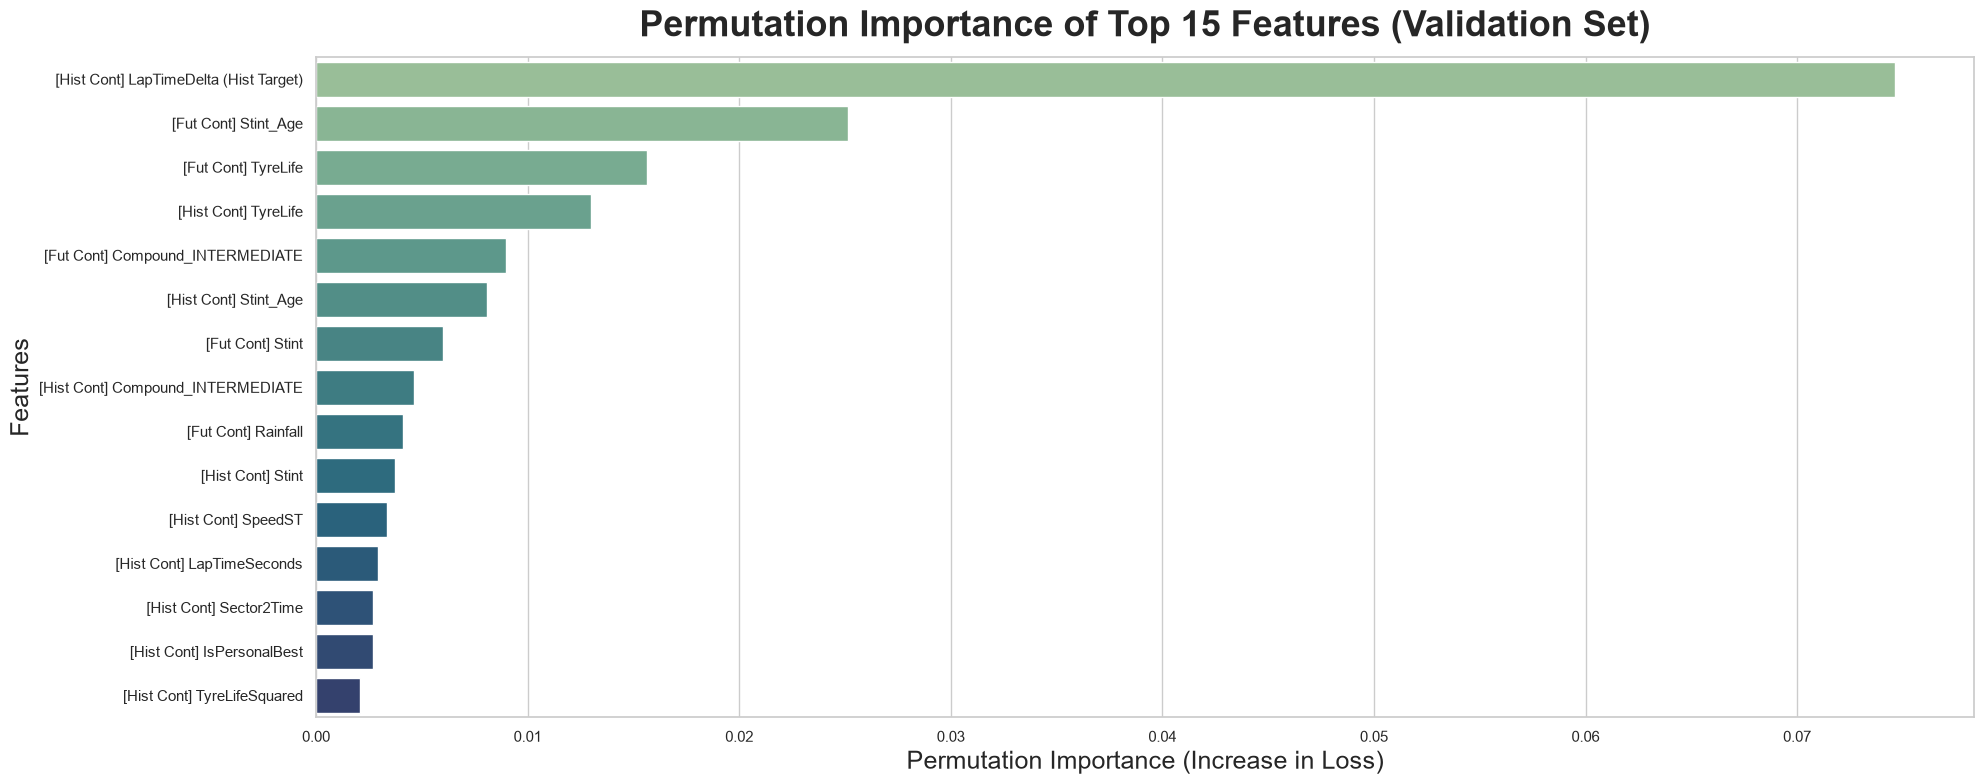

In [351]:
# Visualize the Permutation Importance as a Bar Chart

importance_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
features_df = pd.DataFrame(importance_items, columns=['Feature', 'Importance'])
features_df.to_csv(results_dir / "permutation_importance.csv")

# only keep top 20 features for better visualization
features_df = features_df.head(15)

plt.figure(figsize=(20, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',
    data=features_df.head(15),
    palette='crest',
    legend=False
)

plt.title("Permutation Importance of Top 15 Features (Validation Set)", fontsize=26, fontweight='bold', pad=15)
plt.xlabel("Permutation Importance (Increase in Loss)", fontsize=18)
plt.ylabel("Features", fontsize=18)
plt.tight_layout()
plt.savefig(feature_plots_dir / "01_Permutation_Importance_Validation_Set.png", dpi=300, bbox_inches='tight')
plt.show()

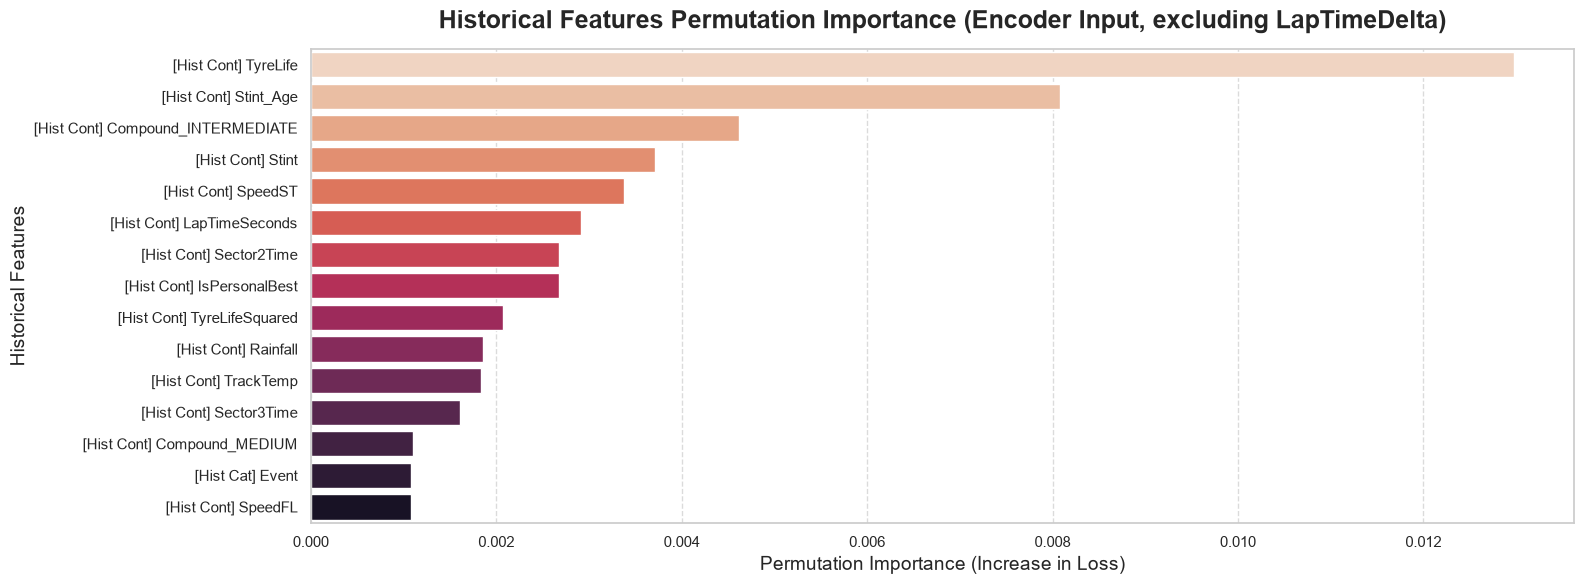

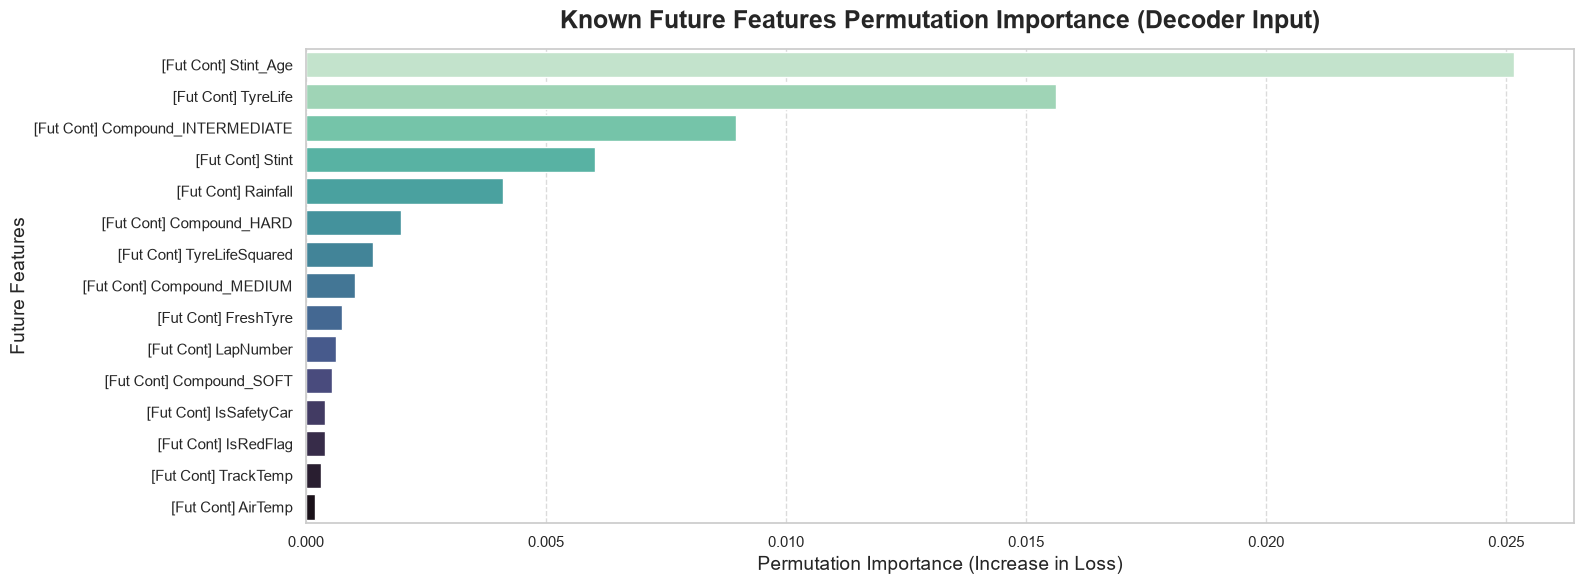

In [350]:
# Separate Historical and Known Future Features for clearer visualization

# 1. Sort the importance dictionary and convert it to a DataFrame for better visualization
importance_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
df_importance = pd.DataFrame(importance_items, columns=['Feature', 'Importance'])

# 2. Separate Historical and Known Future Features for clearer visualization
df_hist = df_importance[df_importance['Feature'].str.startswith('[Hist')].copy()
df_fut = df_importance[df_importance['Feature'].str.startswith('[Fut')].copy()

# Remove the name prefixes to make the chart Y-axis labels cleaner
df_hist['Clean_Feature'] = df_hist['Feature'].str.replace(r'\[Hist (Cat|Cont)\] ', '', regex=True)
df_fut['Clean_Feature'] = df_fut['Feature'].str.replace(r'\[Fut (Cat|Cont)\] ', '', regex=True)

# Exclude the LapTimeDelta (target) from the historical features for visualization
df_hist = df_hist[df_hist['Clean_Feature'] != 'LapTimeDelta (Hist Target)']

# -------------------------------------------------------------------------
# Plot 1: Historical Features Importance (Encoder Input)
# -------------------------------------------------------------------------
plt.figure(figsize=(16, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',
    data=df_hist.head(15),
    palette='rocket_r',
    legend=False
)

plt.title("Historical Features Permutation Importance (Encoder Input, excluding LapTimeDelta)", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Permutation Importance (Increase in Loss)", fontsize=14)
plt.ylabel("Historical Features", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(feature_plots_dir / "02_Historical_Features_Importance.png", dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------
# Plot 2: Known Future Features Importance (Decoder Input)
# -------------------------------------------------------------------------
plt.figure(figsize=(16, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',
    data=df_fut.head(15),
    palette='mako_r',
    legend=False
)

plt.title("Known Future Features Permutation Importance (Decoder Input)", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Permutation Importance (Increase in Loss)", fontsize=14)
plt.ylabel("Future Features", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(feature_plots_dir / "03_Known_Future_Features_Importance.png", dpi=300, bbox_inches='tight')
plt.show()

# Saving Artifacts

In [353]:
# Save the preprocessor and dataset tensors for future use in the application

# Save the Preprocessor for Future Use
joblib.dump(preprocessor, "models/preprocessor.joblib")

# Save the Validation Tensors for Future Use
def extract_tensor_dict(dataset, df, split_name="Train"):
    x_cat, x_cont, x_cat_fut, x_cont_fut, y = [], [], [], [], []
    
    for i in range(len(dataset)):
        sample = dataset[i]
        x_cat.append(sample[0])
        x_cont.append(sample[1])
        x_cat_fut.append(sample[2])
        x_cont_fut.append(sample[3])
        y.append(sample[4])

    meta_df = df[['Year', 'Event', 'Driver', 'LapNumber']].iloc[:len(dataset)].reset_index(drop=True)
    meta_df['Split'] = split_name

    # Check length
    if len(x_cat) != len(meta_df):
        raise ValueError(f"Length mismatch: x_cat has {len(x_cat)} samples, but meta_df has {len(meta_df)} rows.")
    else:
        print(f"[{split_name}] Length check passed: {len(x_cat)} samples.")

    return {
        "x_cat": torch.stack(x_cat),
        "x_cont": torch.stack(x_cont),
        "x_cat_fut": torch.stack(x_cat_fut),
        "x_cont_fut": torch.stack(x_cont_fut),
        "y": torch.stack(y),
        "meta": meta_df
    }

# Create tensor dictionaries for train, validation, and test datasets
train_tensors = extract_tensor_dict(train_dataset, train_df, split_name="Train")
val_tensors = extract_tensor_dict(val_dataset, val_df, split_name="Validation")
test_tensors = extract_tensor_dict(test_dataset, test_df, split_name="Test")

# Merge all tensors into a single dictionary for saving
all_tensors = {
    "x_cat": torch.cat([train_tensors["x_cat"], val_tensors["x_cat"], test_tensors["x_cat"]], dim=0),
    "x_cont": torch.cat([train_tensors["x_cont"], val_tensors["x_cont"], test_tensors["x_cont"]], dim=0),
    "x_cat_fut": torch.cat([train_tensors["x_cat_fut"], val_tensors["x_cat_fut"], test_tensors["x_cat_fut"]], dim=0),
    "x_cont_fut": torch.cat([train_tensors["x_cont_fut"], val_tensors["x_cont_fut"], test_tensors["x_cont_fut"]], dim=0),
    "y": torch.cat([train_tensors["y"], val_tensors["y"], test_tensors["y"]], dim=0),
    "meta": pd.concat([train_tensors["meta"], val_tensors["meta"], test_tensors["meta"]], ignore_index=True)
}

torch.save(all_tensors, "models/all_tensors.pt")


print("Saved Preprocessor and Dataset Tensors for future use in the application.")

[Train] Length check passed: 53842 samples.
[Validation] Length check passed: 16860 samples.
[Test] Length check passed: 15629 samples.
Saved Preprocessor and Dataset Tensors for future use in the application.


In [393]:
# Save the evaluation results

# 1.Forecast Horizon Error
# Add an identifier column to each
horizon_df["Model_Split"]           = "Base Model (Val)"
horizon_df_best_val["Model_Split"]  = "Tuned Model (Val)"
horizon_df_best_test["Model_Split"] = "Tuned Model (Test)"

combined_horizon_df = pd.concat(
    [horizon_df, horizon_df_best_val, horizon_df_best_test], ignore_index=True
)

combined_horizon_df.to_parquet(
    results_dir / "model_horizon_comparison.parquet", index=False
)


# 2. Residuals stats
df_base_val  = pd.DataFrame([stats])
df_best_val  = pd.DataFrame([stats_best_val])
df_best_test = pd.DataFrame([stats_best_test])

df_base_val["Model_Split"] = "Base Model (Val)"
df_best_val["Model_Split"] = "Tuned Model (Val)"
df_best_test["Model_Split"] = "Tuned Model (Test)"

combined_stats_df =  pd.concat(
    [df_base_val, df_best_val, df_best_test], ignore_index=True
)

combined_stats_df.to_parquet(
    results_dir / "model_residual_stat_comparison.parquet", index=False
)


import pandas as pd

# 3. Residuals array
df_residuals = pd.concat(
    [
        pd.DataFrame({"Residual": residuals, "Model_Split": "Base Model (Val)"}),
        pd.DataFrame({"Residual": residuals_best_val, "Model_Split": "Tuned Model (Val)"}),
        pd.DataFrame({"Residual": residuals_best_test,"Model_Split": "Tuned Model (Test)",}),
    ],
    ignore_index=True,
)

df_residuals.to_parquet(
    results_dir / "model_residuals_comparison.parquet", index=False
)
